In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
agra=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\raw_data\Cars24_Agra_raw.csv')
bangalore=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\raw_data\cars24_banglore_raw.csv')
chandigarh=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\raw_data\Cars24_Chandigarh_raw.csv')
chennai=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\raw_data\cars24_Chennai_raw.csv')
coimbatore=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\raw_data\Cars24_Coimbatore_raw.csv')
hyderabad=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\raw_data\cars24_hyderabad_raw.csv')
indore=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\raw_data\Cars24_Indore_raw.csv')
jaipur=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\raw_data\Cars24_Jaipur_raw.csv')
kochi=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\raw_data\Cars24_Kochi_raw.csv')
kolkata=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\raw_data\cars24_Kolkata_raw.csv')
mumbai=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\raw_data\cars24_mumbai_raw.csv')
nashik=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\raw_data\Cars24_Nashik_raw.csv')
patna=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\raw_data\Cars24_Patna_raw.csv')
pune=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\raw_data\Cars24_Pune_raw.csv')
rajkot=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\raw_data\Cars24_Rajkot_raw.csv')
surat=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\raw_data\Cars24_Surat_raw.csv')


In [3]:
#Basic understanding
agra.head()

,Unnamed: 0,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,0,Maruti Alto 800,Maruti,2013,"59,183 km",Petrol,Manual,"EMI ₹8,084/m*",₹1.72 lakh
1,1,Tata TIGOR,Tata,2018,"60,000 km",Petrol,Manual,"EMI ₹5,737/m*",₹3.25 lakh
2,2,Hyundai Creta,Hyundai,2018,"77,164 km",Diesel,Manual,"EMI ₹12,871/m*",₹6.58 lakh
3,3,Mahindra Kuv100,Mahindra,2016,"92,583 km",Diesel,Manual,"EMI ₹6,683/m*",₹2.54 lakh
4,4,Mahindra Kuv100,Mahindra,2018,"44,360 km",Petrol,Manual,"EMI ₹5,649/m*",₹3.20 lakh


In [4]:
#Drop the Unwanted column
agra.drop(columns=["Unnamed: 0"], inplace=True)

In [5]:
agra.head()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Maruti Alto 800,Maruti,2013,"59,183 km",Petrol,Manual,"EMI ₹8,084/m*",₹1.72 lakh
1,Tata TIGOR,Tata,2018,"60,000 km",Petrol,Manual,"EMI ₹5,737/m*",₹3.25 lakh
2,Hyundai Creta,Hyundai,2018,"77,164 km",Diesel,Manual,"EMI ₹12,871/m*",₹6.58 lakh
3,Mahindra Kuv100,Mahindra,2016,"92,583 km",Diesel,Manual,"EMI ₹6,683/m*",₹2.54 lakh
4,Mahindra Kuv100,Mahindra,2018,"44,360 km",Petrol,Manual,"EMI ₹5,649/m*",₹3.20 lakh


In [6]:
agra.tail()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
440,Mahindra XUV700,Mahindra,2021,"1,11,228 km",Petrol,Auto,"EMI ₹30,613/m*",₹14.08 lakh
441,Maruti Swift,Maruti,2014,"75,496 km",Diesel,Manual,"EMI ₹12,004/m*",₹2.55 lakh
442,Maruti Ritz,Maruti,2013,"78,840 km",Diesel,Manual,"EMI ₹14,127/m*",₹1.59 lakh
443,Maruti Alto K10,Maruti,2014,"94,403 km",Petrol,Manual,"EMI ₹5,414/m*",₹1.63 lakh
444,MG HECTOR,MG,2019,"84,802 km",Diesel,Manual,"EMI ₹17,550/m*",₹10.25 lakh


In [7]:
#Standardize column names
agra.columns = agra.columns.str.strip().str.lower().str.replace(" ", "_")

In [8]:
agra.columns

Index(['car_name', 'brand', 'year_of_manufacture', 'distance_driven',
       'fuel_type', 'transmission_type', 'emi', 'price'],
      dtype='object')

In [9]:
agra.dtypes

car_name               object
brand                  object
year_of_manufacture     int64
distance_driven        object
fuel_type              object
transmission_type      object
emi                    object
price                  object
dtype: object

In [10]:
#Clean Price Column (₹, commas, text)
agra["price"] = agra["price"].astype(str)
agra["price"] = agra["price"].str.replace("₹", "").str.replace(",", "")

In [11]:
#Convert lakh to numeric rupees
agra.loc[
    agra["price"].str.contains("lakh", na=False),
    "price"
] = (
    agra.loc[
        agra["price"].str.contains("lakh", na=False),
        "price"
    ]
    .str.replace("lakh", "", regex=False)
    .astype(float) * 100000
)

In [12]:
#Convert column to numeric
agra["price"] = pd.to_numeric(agra["price"], errors="coerce")

In [13]:
#Clean EMI Column
agra["emi"] = agra["emi"].astype(str)

agra["emi"] = (
    agra["emi"]
    .str.replace("EMI", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("/m*", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convert to numeric
agra["emi"] = pd.to_numeric(agra["emi"], errors="coerce")


In [14]:
#Clean Distance Driven Column
agra["distance_driven"] = (
    agra["distance_driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
agra["distance_driven"] = pd.to_numeric(agra["distance_driven"], errors="coerce")

In [15]:
agra.head()

,car_name,brand,year_of_manufacture,distance_driven,fuel_type,transmission_type,emi,price
0,Maruti Alto 800,Maruti,2013,59183,Petrol,Manual,8084,172000.0
1,Tata TIGOR,Tata,2018,60000,Petrol,Manual,5737,325000.0
2,Hyundai Creta,Hyundai,2018,77164,Diesel,Manual,12871,658000.0
3,Mahindra Kuv100,Mahindra,2016,92583,Diesel,Manual,6683,254000.0
4,Mahindra Kuv100,Mahindra,2018,44360,Petrol,Manual,5649,320000.0


In [16]:
agra.dtypes

car_name                object
brand                   object
year_of_manufacture      int64
distance_driven          int64
fuel_type               object
transmission_type       object
emi                      int64
price                  float64
dtype: object

In [17]:
agra.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             445 non-null    object 
 1   brand                445 non-null    object 
 2   year_of_manufacture  445 non-null    int64  
 3   distance_driven      445 non-null    int64  
 4   fuel_type            445 non-null    object 
 5   transmission_type    445 non-null    object 
 6   emi                  445 non-null    int64  
 7   price                445 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 27.9+ KB


In [18]:
agra.describe()

,year_of_manufacture,distance_driven,emi,price
count,445.000000,4.450000e+02,445.000000,4.450000e+02
mean,2017.323596,3.101921e+05,13367.294382,5.540697e+05
std,3.757096,4.736669e+06,9646.548766,5.048765e+05
min,2010.000000,2.680000e+02,1869.000000,4.400000e+04
25%,2014.000000,5.015200e+04,7479.000000,2.300000e+05
50%,2017.000000,7.700000e+04,10150.000000,3.870000e+05
75%,2020.000000,1.116540e+05,15571.000000,6.580000e+05
max,2025.000000,1.000000e+08,76315.000000,4.457000e+06


In [19]:
print("Before outlier removal:", agra.shape)

Before outlier removal: (445, 8)


In [ ]:
#Outlier handling
agra= agra[
    (agra["price"] > 50000) &
    (agra["price"] < 5000000) &
    (agra["distance_driven"] < 500000)
]

In [21]:
print("after outlier removal:", agra.shape)

after outlier removal: (443, 8)


In [22]:
agra.duplicated().sum()

np.int64(0)

In [23]:
agra.isnull().sum()

car_name               0
brand                  0
year_of_manufacture    0
distance_driven        0
fuel_type              0
transmission_type      0
emi                    0
price                  0
dtype: int64

In [24]:
##BASIC DATA UNDERSTANDING
#Head:see sample rows
bangalore.head()

,Unnamed: 0,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,0,Honda Jazz,Honda,2018,"47,411 km",Petrol,Auto,"EMI ₹11,474/m*",₹6.50 lakh
1,1,Maruti Vitara Brezza,Maruti,2018,"55,196 km",Diesel,Auto,"EMI ₹15,249/m*",₹7.80 lakh
2,2,Ford Figo Aspire,Ford,2017,"42,174 km",Petrol,Manual,"EMI ₹7,656/m*",₹3.92 lakh
3,3,Hyundai Creta,Hyundai,2024,"8,823 km",Petrol,Auto,"EMI ₹30,820/m*",₹18.00 lakh
4,4,Renault Kwid,Renault,2017,"49,297 km",Petrol,Auto,"EMI ₹5,762/m*",₹2.95 lakh


In [25]:
#Drop the Unwanted column
bangalore.drop(columns=["Unnamed: 0"], inplace=True)

In [26]:
bangalore.head()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Honda Jazz,Honda,2018,"47,411 km",Petrol,Auto,"EMI ₹11,474/m*",₹6.50 lakh
1,Maruti Vitara Brezza,Maruti,2018,"55,196 km",Diesel,Auto,"EMI ₹15,249/m*",₹7.80 lakh
2,Ford Figo Aspire,Ford,2017,"42,174 km",Petrol,Manual,"EMI ₹7,656/m*",₹3.92 lakh
3,Hyundai Creta,Hyundai,2024,"8,823 km",Petrol,Auto,"EMI ₹30,820/m*",₹18.00 lakh
4,Renault Kwid,Renault,2017,"49,297 km",Petrol,Auto,"EMI ₹5,762/m*",₹2.95 lakh


In [27]:
bangalore.tail()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
2387,Renault Duster,Renault,2017,"47,171 km",Petrol,Manual,"EMI ₹9,775/m*",₹5.00 lakh
2388,Hyundai i20,Hyundai,2014,"62,552 km",Petrol,Manual,"EMI ₹12,911/m*",₹3.89 lakh
2389,KIA SONET,KIA,2023,"25,105 km",Diesel,Manual,"EMI ₹19,828/m*",₹11.58 lakh
2390,Mahindra XUV700,Mahindra,2022,"65,429 km",Petrol,Manual,"EMI ₹24,240/m*",₹14.16 lakh
2391,Volkswagen Polo,Volkswagen,2021,"18,476 km",Petrol,Auto,"EMI ₹15,262/m*",₹8.91 lakh


In [28]:
#Standardize column names
bangalore.columns = bangalore.columns.str.strip().str.lower().str.replace(" ", "_")


In [29]:
bangalore.columns

Index(['car_name', 'brand', 'year_of_manufacture', 'distance_driven',
       'fuel_type', 'transmission_type', 'emi', 'price'],
      dtype='object')

In [30]:
bangalore.dtypes

car_name               object
brand                  object
year_of_manufacture     int64
distance_driven        object
fuel_type              object
transmission_type      object
emi                    object
price                  object
dtype: object

In [31]:
#Clean Price Column (₹, commas, text)
bangalore["price"] = bangalore["price"].astype(str)
bangalore["price"] = bangalore["price"].str.replace("₹", "").str.replace(",", "")

In [32]:
#Convert lakh to numeric rupees
bangalore.loc[
    bangalore["price"].str.contains("lakh", na=False),
    "price"
] = (
    bangalore.loc[
        bangalore["price"].str.contains("lakh", na=False),
        "price"
    ]
    .str.replace("lakh", "", regex=False)
    .astype(float) * 100000
)

In [33]:
#Convert column to numeric
bangalore["price"] = pd.to_numeric(bangalore["price"], errors="coerce")

In [34]:
#Clean EMI Column
bangalore["emi"] = bangalore["emi"].astype(str)

bangalore["emi"] = (
    bangalore["emi"]
    .str.replace("EMI", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("/m*", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convert to numeric
bangalore["emi"] = pd.to_numeric(bangalore["emi"], errors="coerce")


In [35]:
#Clean Distance Driven Column
bangalore["distance_driven"] = (
    bangalore["distance_driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
bangalore["distance_driven"] = pd.to_numeric(bangalore["distance_driven"], errors="coerce")

In [36]:
bangalore.head()

,car_name,brand,year_of_manufacture,distance_driven,fuel_type,transmission_type,emi,price
0,Honda Jazz,Honda,2018,47411,Petrol,Auto,11474,650000.0
1,Maruti Vitara Brezza,Maruti,2018,55196,Diesel,Auto,15249,780000.0
2,Ford Figo Aspire,Ford,2017,42174,Petrol,Manual,7656,392000.0
3,Hyundai Creta,Hyundai,2024,8823,Petrol,Auto,30820,1800000.0
4,Renault Kwid,Renault,2017,49297,Petrol,Auto,5762,295000.0


In [37]:
bangalore.dtypes

car_name                object
brand                   object
year_of_manufacture      int64
distance_driven          int64
fuel_type               object
transmission_type       object
emi                      int64
price                  float64
dtype: object

In [38]:
bangalore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             2392 non-null   object 
 1   brand                2392 non-null   object 
 2   year_of_manufacture  2392 non-null   int64  
 3   distance_driven      2392 non-null   int64  
 4   fuel_type            2392 non-null   object 
 5   transmission_type    2392 non-null   object 
 6   emi                  2392 non-null   int64  
 7   price                2392 non-null   float64
dtypes: float64(1), int64(3), object(4)
memory usage: 149.6+ KB


In [39]:
bangalore.describe()

,year_of_manufacture,distance_driven,emi,price
count,2392.000000,2392.000000,2392.000000,2.392000e+03
mean,2017.429348,68280.440635,14294.903010,5.926998e+05
std,3.717438,44421.588744,8012.405743,3.279298e+05
min,2006.000000,111.000000,2933.000000,5.000000e+04
25%,2015.000000,37445.500000,9580.000000,3.500000e+05
50%,2017.000000,61176.000000,12710.000000,5.215000e+05
75%,2021.000000,90175.750000,16881.500000,7.592500e+05
max,2025.000000,700001.000000,102876.000000,2.212000e+06


In [40]:
print("Before outlier removal:", bangalore.shape)

Before outlier removal: (2392, 8)


In [41]:
#Outlier handling
bangalore = bangalore[
    (bangalore["price"] > 50000) &
    (bangalore["price"] < 5000000) &
    (bangalore["distance_driven"] < 500000)
]

In [42]:
print("after outlier removal:", bangalore.shape)

after outlier removal: (2389, 8)


In [43]:
bangalore.isna().sum()

car_name               0
brand                  0
year_of_manufacture    0
distance_driven        0
fuel_type              0
transmission_type      0
emi                    0
price                  0
dtype: int64

In [44]:
#counting duplicates
bangalore.duplicated().sum()

np.int64(0)

In [45]:
##BASIC DATA UNDERSTANDING
#Head:see sample rows
chandigarh.head()

,Unnamed: 0,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,0,Hyundai ALCAZAR,Hyundai,2022,"26,698 km",Petrol,Manual,"EMI ₹19,348/m*",₹11.30 lakh
1,1,Ford Ecosport,Ford,2016,"84,622 km",Diesel,Manual,"EMI ₹9,356/m*",₹3.55 lakh
2,2,Maruti Swift,Maruti,2018,"37,239 km",Petrol,Manual,"EMI ₹6,708/m*",₹3.80 lakh
3,3,Tata Indigo ECS,Tata,2015,"96,240 km",Diesel,Manual,"EMI ₹4,646/m*",₹1.40 lakh
4,4,Tata Tiago,Tata,2022,"14,740 km",Petrol,Manual,"EMI ₹8,297/m*",₹4.70 lakh


In [46]:
#Drop the Unwanted column
chandigarh.drop(columns=["Unnamed: 0"], inplace=True)

In [47]:
chandigarh.head()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Hyundai ALCAZAR,Hyundai,2022,"26,698 km",Petrol,Manual,"EMI ₹19,348/m*",₹11.30 lakh
1,Ford Ecosport,Ford,2016,"84,622 km",Diesel,Manual,"EMI ₹9,356/m*",₹3.55 lakh
2,Maruti Swift,Maruti,2018,"37,239 km",Petrol,Manual,"EMI ₹6,708/m*",₹3.80 lakh
3,Tata Indigo ECS,Tata,2015,"96,240 km",Diesel,Manual,"EMI ₹4,646/m*",₹1.40 lakh
4,Tata Tiago,Tata,2022,"14,740 km",Petrol,Manual,"EMI ₹8,297/m*",₹4.70 lakh


In [48]:
#Standardize column names
chandigarh.columns = chandigarh.columns.str.strip().str.lower().str.replace(" ", "_")

In [49]:
chandigarh.columns

Index(['car_name', 'brand', 'year_of_manufacture', 'distance_driven',
       'fuel_type', 'transmission_type', 'emi', 'price'],
      dtype='object')

In [50]:
chandigarh.dtypes

car_name               object
brand                  object
year_of_manufacture     int64
distance_driven        object
fuel_type              object
transmission_type      object
emi                    object
price                  object
dtype: object

In [51]:
#Clean Price Column (₹, commas, text)
chandigarh["price"] = chandigarh["price"].astype(str)
chandigarh["price"] = chandigarh["price"].str.replace("₹", "").str.replace(",", "")

In [52]:
#Convert lakh to numeric rupees
chandigarh.loc[
    chandigarh["price"].str.contains("lakh", na=False),
    "price"
] = (
    chandigarh.loc[
        chandigarh["price"].str.contains("lakh", na=False),
        "price"
    ]
    .str.replace("lakh", "", regex=False)
    .astype(float) * 100000
)

In [53]:
#Convert column to numeric
chandigarh["price"] = pd.to_numeric(chandigarh["price"], errors="coerce")

In [54]:
#Clean EMI Column
chandigarh["emi"] = chandigarh["emi"].astype(str)

chandigarh["emi"] = (
    chandigarh["emi"]
    .str.replace("EMI", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("/m*", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convert to numeric
chandigarh["emi"] = pd.to_numeric(chandigarh["emi"], errors="coerce")

In [55]:
#Clean Distance Driven Column
chandigarh["distance_driven"] = (
    chandigarh["distance_driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
chandigarh["distance_driven"] = pd.to_numeric(chandigarh["distance_driven"], errors="coerce")

In [56]:
chandigarh.head()

,car_name,brand,year_of_manufacture,distance_driven,fuel_type,transmission_type,emi,price
0,Hyundai ALCAZAR,Hyundai,2022,26698,Petrol,Manual,19348,1130000.0
1,Ford Ecosport,Ford,2016,84622,Diesel,Manual,9356,355000.0
2,Maruti Swift,Maruti,2018,37239,Petrol,Manual,6708,380000.0
3,Tata Indigo ECS,Tata,2015,96240,Diesel,Manual,4646,140000.0
4,Tata Tiago,Tata,2022,14740,Petrol,Manual,8297,470000.0


In [57]:
chandigarh.tail()

,car_name,brand,year_of_manufacture,distance_driven,fuel_type,transmission_type,emi,price
180,Mahindra XUV500,Mahindra,2015,117054,Diesel,Manual,15578,469000.0
181,Tata NEXON,Tata,2019,38113,Diesel,Manual,12322,698000.0
182,Tata TIGOR,Tata,2017,184323,Diesel,Manual,6715,302000.0
183,Maruti Vitara Brezza,Maruti,2021,62271,Petrol,Manual,9656,547000.0
184,Mercedes Benz C Class,Mercedes,2020,45230,Diesel,Auto,56264,3286000.0


In [58]:
chandigarh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             185 non-null    object 
 1   brand                185 non-null    object 
 2   year_of_manufacture  185 non-null    int64  
 3   distance_driven      185 non-null    int64  
 4   fuel_type            185 non-null    object 
 5   transmission_type    185 non-null    object 
 6   emi                  185 non-null    int64  
 7   price                185 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 11.7+ KB


In [59]:
chandigarh.describe()

,year_of_manufacture,distance_driven,emi,price
count,185.000000,185.000000,185.000000,1.850000e+02
mean,2018.075676,90471.156757,15144.091892,6.761514e+05
std,3.559235,50053.538303,12408.185684,6.113997e+05
min,2011.000000,2900.000000,3389.000000,1.060000e+05
25%,2016.000000,54775.000000,7541.000000,3.020000e+05
50%,2018.000000,85512.000000,11245.000000,4.840000e+05
75%,2021.000000,128154.000000,17305.000000,8.510000e+05
max,2025.000000,273601.000000,82188.000000,4.800000e+06


In [60]:
print("Before outlier removal:", chandigarh.shape)

Before outlier removal: (185, 8)


In [61]:
#Outlier handling
chandigarh= chandigarh[
    (chandigarh["price"] > 50000) &
    (chandigarh["price"] < 5000000) &
    (chandigarh["distance_driven"] < 500000)
]

In [62]:
print("after outlier removal:", chandigarh.shape)

after outlier removal: (185, 8)


In [63]:
#counting duplicates
chandigarh.duplicated().sum()

np.int64(0)

In [64]:
chandigarh.isna().sum()

car_name               0
brand                  0
year_of_manufacture    0
distance_driven        0
fuel_type              0
transmission_type      0
emi                    0
price                  0
dtype: int64

In [65]:
##BASIC DATA UNDERSTANDING
#Head:see sample rows
chennai.head()

,Unnamed: 0,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,0,Renault Kwid,Renault,2016,"77,314 km",Petrol,Manual,"EMI ₹5,558/m*",₹2.50 lakh
1,1,Maruti Alto 800,Maruti,2012,"60,998 km",Petrol,Manual,"EMI ₹15,774/m*",₹1.78 lakh
2,2,Renault Kwid,Renault,2016,"48,002 km",Petrol,Manual,"EMI ₹4,449/m*",₹2.00 lakh
3,3,Hyundai i20,Hyundai,2013,"1,03,608 km",Petrol,Manual,"EMI ₹13,257/m*",₹2.82 lakh
4,4,Maruti Swift,Maruti,2017,"99,975 km",Diesel,Manual,"EMI ₹10,865/m*",₹4.88 lakh


In [66]:
#Drop the Unwanted column
chennai.drop(columns=["Unnamed: 0"], inplace=True)

In [67]:
chennai.head()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Renault Kwid,Renault,2016,"77,314 km",Petrol,Manual,"EMI ₹5,558/m*",₹2.50 lakh
1,Maruti Alto 800,Maruti,2012,"60,998 km",Petrol,Manual,"EMI ₹15,774/m*",₹1.78 lakh
2,Renault Kwid,Renault,2016,"48,002 km",Petrol,Manual,"EMI ₹4,449/m*",₹2.00 lakh
3,Hyundai i20,Hyundai,2013,"1,03,608 km",Petrol,Manual,"EMI ₹13,257/m*",₹2.82 lakh
4,Maruti Swift,Maruti,2017,"99,975 km",Diesel,Manual,"EMI ₹10,865/m*",₹4.88 lakh


In [68]:
chennai.tail()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
606,Maruti S PRESSO,Maruti,2021,"39,389 km",Petrol,Auto,"EMI ₹7,013/m*",₹3.97 lakh
607,Hyundai Grand i10,Hyundai,2019,"52,441 km",Petrol,Manual,"EMI ₹6,938/m*",₹3.93 lakh
608,Tata NEXON,Tata,2022,"67,305 km",Petrol,Manual,"EMI ₹11,418/m*",₹6.47 lakh
609,Nissan MAGNITE,Nissan,2021,"25,621 km",Petrol,Auto,"EMI ₹11,327/m*",₹6.42 lakh
610,Maruti S Cross,Maruti,2018,"43,708 km",Diesel,Manual,"EMI ₹12,549/m*",₹6.42 lakh


In [69]:
#Standardize column names
chennai.columns = chennai.columns.str.strip().str.lower().str.replace(" ", "_")


In [70]:
chennai.columns

Index(['car_name', 'brand', 'year_of_manufacture', 'distance_driven',
       'fuel_type', 'transmission_type', 'emi', 'price'],
      dtype='object')

In [71]:
chennai.dtypes

car_name               object
brand                  object
year_of_manufacture     int64
distance_driven        object
fuel_type              object
transmission_type      object
emi                    object
price                  object
dtype: object

In [72]:
#Clean Price Column (₹, commas, text)
chennai["price"] = chennai["price"].astype(str)
chennai["price"] = chennai["price"].str.replace("₹", "").str.replace(",", "")

In [73]:
#Convert lakh to numeric rupees
chennai.loc[
   chennai["price"].str.contains("lakh", na=False),
    "price"
] = (
    chennai.loc[
        chennai["price"].str.contains("lakh", na=False),
        "price"
    ]
    .str.replace("lakh", "", regex=False)
    .astype(float) * 100000
)

In [74]:
#Convert column to numeric
chennai["price"] = pd.to_numeric(chennai["price"], errors="coerce")

In [75]:
#Clean EMI Column
chennai["emi"] = chennai["emi"].astype(str)

chennai["emi"] = (
    chennai["emi"]
    .str.replace("EMI", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("/m*", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convert to numeric
chennai["emi"] = pd.to_numeric(chennai["emi"], errors="coerce")

In [76]:
#Clean Distance Driven Column
chennai["distance_driven"] = (
    chennai["distance_driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
chennai["distance_driven"] = pd.to_numeric(chennai["distance_driven"], errors="coerce")

In [77]:
chennai.head()

,car_name,brand,year_of_manufacture,distance_driven,fuel_type,transmission_type,emi,price
0,Renault Kwid,Renault,2016,77314,Petrol,Manual,5558,250000.0
1,Maruti Alto 800,Maruti,2012,60998,Petrol,Manual,15774,178000.0
2,Renault Kwid,Renault,2016,48002,Petrol,Manual,4449,200000.0
3,Hyundai i20,Hyundai,2013,103608,Petrol,Manual,13257,282000.0
4,Maruti Swift,Maruti,2017,99975,Diesel,Manual,10865,488000.0


In [78]:
chennai.dtypes

car_name                object
brand                   object
year_of_manufacture      int64
distance_driven          int64
fuel_type               object
transmission_type       object
emi                      int64
price                  float64
dtype: object

In [79]:
chennai.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 611 entries, 0 to 610
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             611 non-null    object 
 1   brand                611 non-null    object 
 2   year_of_manufacture  611 non-null    int64  
 3   distance_driven      611 non-null    int64  
 4   fuel_type            611 non-null    object 
 5   transmission_type    611 non-null    object 
 6   emi                  611 non-null    int64  
 7   price                611 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 38.3+ KB


In [80]:
chennai.describe()

,year_of_manufacture,distance_driven,emi,price
count,611.000000,611.000000,611.000000,6.110000e+02
mean,2017.955810,67416.891980,12985.973813,5.588101e+05
std,3.681546,39494.414247,9877.495956,3.376844e+05
min,2010.000000,2.000000,2777.000000,5.900000e+04
25%,2015.000000,37198.500000,8455.500000,3.350000e+05
50%,2018.000000,62125.000000,11033.000000,4.900000e+05
75%,2021.000000,91914.500000,14286.500000,6.730000e+05
max,2025.000000,252886.000000,133191.000000,2.460000e+06


In [81]:
print("Before outlier removal:", chennai.shape)

Before outlier removal: (611, 8)


In [82]:
# ooutlier handling
chennai = chennai[
    (chennai["price"] > 50000) &
    (chennai["price"] < 5000000) &
    (chennai["distance_driven"] < 500000)
]

In [83]:
print("after outlier removal:", chennai.shape)

after outlier removal: (611, 8)


In [84]:
chennai.duplicated().sum()

np.int64(0)

In [85]:
chennai.isna().sum()

car_name               0
brand                  0
year_of_manufacture    0
distance_driven        0
fuel_type              0
transmission_type      0
emi                    0
price                  0
dtype: int64

In [86]:
##BASIC DATA UNDERSTANDING
#Head:see sample rows
coimbatore.head()

,Unnamed: 0,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,0,Hyundai Eon,Hyundai,2015,"84,569 km",Petrol,Manual,"EMI ₹3,318/m*",₹1.26 lakh
1,1,Honda City,Honda,2014,"1,18,794 km",Diesel,Manual,"EMI ₹9,980/m*",₹2.12 lakh
2,2,Honda Amaze,Honda,2013,"1,66,700 km",Diesel,Manual,"EMI ₹13,949/m*",₹1.57 lakh
3,3,Maruti Swift,Maruti,2023,"35,442 km",Petrol,Manual,"EMI ₹9,550/m*",₹5.41 lakh
4,4,Hyundai Grand i10,Hyundai,2018,"1,06,672 km",Petrol,Manual,"EMI ₹7,185/m*",₹3.23 lakh


In [87]:
#Drop the Unwanted column
coimbatore.drop(columns=["Unnamed: 0"], inplace=True)

In [88]:
coimbatore.head()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Hyundai Eon,Hyundai,2015,"84,569 km",Petrol,Manual,"EMI ₹3,318/m*",₹1.26 lakh
1,Honda City,Honda,2014,"1,18,794 km",Diesel,Manual,"EMI ₹9,980/m*",₹2.12 lakh
2,Honda Amaze,Honda,2013,"1,66,700 km",Diesel,Manual,"EMI ₹13,949/m*",₹1.57 lakh
3,Maruti Swift,Maruti,2023,"35,442 km",Petrol,Manual,"EMI ₹9,550/m*",₹5.41 lakh
4,Hyundai Grand i10,Hyundai,2018,"1,06,672 km",Petrol,Manual,"EMI ₹7,185/m*",₹3.23 lakh


In [89]:
#Standardize column names
coimbatore.columns = coimbatore.columns.str.strip().str.lower().str.replace(" ", "_")

In [90]:
coimbatore.columns

Index(['car_name', 'brand', 'year_of_manufacture', 'distance_driven',
       'fuel_type', 'transmission_type', 'emi', 'price'],
      dtype='object')

In [91]:
coimbatore.dtypes

car_name               object
brand                  object
year_of_manufacture     int64
distance_driven        object
fuel_type              object
transmission_type      object
emi                    object
price                  object
dtype: object

In [92]:
#Clean Price Column (₹, commas, text)
coimbatore["price"] = coimbatore["price"].astype(str)
coimbatore["price"] =coimbatore["price"].str.replace("₹", "").str.replace(",", "")

In [93]:
#Convert lakh to numeric rupees
coimbatore.loc[
    coimbatore["price"].str.contains("lakh", na=False),
    "price"
] = (
      coimbatore.loc[
        coimbatore["price"].str.contains("lakh", na=False),
        "price"
    ]
    .str.replace("lakh", "", regex=False)
    .astype(float) * 100000
)

In [94]:
#Convert column to numeric
coimbatore["price"] = pd.to_numeric(coimbatore["price"], errors="coerce")

In [95]:
#Clean EMI Column
coimbatore["emi"] = bangalore["emi"].astype(str)

coimbatore["emi"] = (
    coimbatore["emi"]
    .str.replace("EMI", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("/m*", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convert to numeric
coimbatore["emi"] = pd.to_numeric(coimbatore["emi"], errors="coerce")

In [96]:
#Clean Distance Driven Column
coimbatore["distance_driven"] = (
    coimbatore["distance_driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
coimbatore["distance_driven"] = pd.to_numeric(coimbatore["distance_driven"], errors="coerce")

In [97]:
coimbatore.head()

,car_name,brand,year_of_manufacture,distance_driven,fuel_type,transmission_type,emi,price
0,Hyundai Eon,Hyundai,2015,84569,Petrol,Manual,11474,126000.0
1,Honda City,Honda,2014,118794,Diesel,Manual,15249,212000.0
2,Honda Amaze,Honda,2013,166700,Diesel,Manual,7656,157000.0
3,Maruti Swift,Maruti,2023,35442,Petrol,Manual,30820,541000.0
4,Hyundai Grand i10,Hyundai,2018,106672,Petrol,Manual,5762,323000.0


In [98]:
coimbatore.tail()

,car_name,brand,year_of_manufacture,distance_driven,fuel_type,transmission_type,emi,price
367,Maruti Ertiga,Maruti,2025,20103,Petrol,Manual,18578,983000.0
368,Hyundai Grand i10,Hyundai,2017,73046,Diesel,Manual,7194,251000.0
369,Hyundai NEW SANTRO,Hyundai,2019,13978,Petrol,Manual,9550,368000.0
370,Honda Amaze,Honda,2014,137602,Diesel,Manual,13116,201000.0
371,Maruti Wagon R 1.0,Maruti,2011,119083,Petrol,Manual,20785,114000.0


In [99]:
coimbatore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             372 non-null    object 
 1   brand                372 non-null    object 
 2   year_of_manufacture  372 non-null    int64  
 3   distance_driven      372 non-null    int64  
 4   fuel_type            372 non-null    object 
 5   transmission_type    372 non-null    object 
 6   emi                  372 non-null    int64  
 7   price                372 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 23.4+ KB


In [100]:
coimbatore.describe()

,year_of_manufacture,distance_driven,emi,price
count,372.000000,372.000000,372.000000,3.720000e+02
mean,2017.271505,99258.669355,11811.236559,5.830995e+05
std,4.038086,52460.942063,5175.074728,6.726519e+05
min,2010.000000,4864.000000,3495.000000,4.700000e+04
25%,2014.000000,64153.750000,8473.000000,2.157500e+05
50%,2017.000000,95532.500000,11008.500000,3.865000e+05
75%,2021.000000,130243.000000,13674.750000,7.042500e+05
max,2025.000000,357487.000000,33590.000000,7.500000e+06


In [101]:
print("Before outlier removal:", coimbatore.shape)

Before outlier removal: (372, 8)


In [102]:
#Outlier handling
coimbatore = coimbatore[
    (coimbatore["price"] > 50000) &
    (coimbatore["price"] < 5000000) &
    (coimbatore["distance_driven"] < 500000)
]

In [103]:
print("after outlier removal:", coimbatore.shape)

after outlier removal: (369, 8)


In [104]:
#counting duplicates
coimbatore.duplicated().sum()

np.int64(0)

In [105]:
coimbatore.isna().sum()

car_name               0
brand                  0
year_of_manufacture    0
distance_driven        0
fuel_type              0
transmission_type      0
emi                    0
price                  0
dtype: int64

In [106]:
##BASIC DATA UNDERSTANDING
#Head:see sample rows
indore.head()

,Unnamed: 0,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,0,Hyundai Grand i10,Hyundai,2017,"38,426 km",Petrol,Manual,"EMI ₹7,133/m*",₹3.65 lakh
1,1,Honda City,Honda,2017,"57,094 km",Petrol,Manual,"EMI ₹9,189/m*",₹4.70 lakh
2,2,Volkswagen Polo,Volkswagen,2015,"60,356 km",Petrol,Manual,"EMI ₹7,900/m*",₹3.00 lakh
3,3,Ford FREESTYLE,Ford,2018,"73,353 km",Petrol,Manual,"EMI ₹5,989/m*",₹3.39 lakh
4,4,Renault Kwid,Renault,2020,"70,688 km",Petrol,Manual,"EMI ₹4,855/m*",₹2.75 lakh


In [107]:
#Drop the Unwanted column
indore.drop(columns=["Unnamed: 0"], inplace=True)

In [108]:
indore.head()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Hyundai Grand i10,Hyundai,2017,"38,426 km",Petrol,Manual,"EMI ₹7,133/m*",₹3.65 lakh
1,Honda City,Honda,2017,"57,094 km",Petrol,Manual,"EMI ₹9,189/m*",₹4.70 lakh
2,Volkswagen Polo,Volkswagen,2015,"60,356 km",Petrol,Manual,"EMI ₹7,900/m*",₹3.00 lakh
3,Ford FREESTYLE,Ford,2018,"73,353 km",Petrol,Manual,"EMI ₹5,989/m*",₹3.39 lakh
4,Renault Kwid,Renault,2020,"70,688 km",Petrol,Manual,"EMI ₹4,855/m*",₹2.75 lakh


In [109]:
#Standardize column names
indore.columns = indore.columns.str.strip().str.lower().str.replace(" ", "_")

In [110]:
indore.columns

Index(['car_name', 'brand', 'year_of_manufacture', 'distance_driven',
       'fuel_type', 'transmission_type', 'emi', 'price'],
      dtype='object')

In [111]:
indore.dtypes

car_name               object
brand                  object
year_of_manufacture     int64
distance_driven        object
fuel_type              object
transmission_type      object
emi                    object
price                  object
dtype: object

In [112]:
#Clean Price Column (₹, commas, text)
indore["price"] = indore["price"].astype(str)
indore["price"] = indore["price"].str.replace("₹", "").str.replace(",", "")

In [113]:
#Convert lakh to numeric rupees
indore.loc[
    indore["price"].str.contains("lakh", na=False),
    "price"
] = (
    indore.loc[
        indore["price"].str.contains("lakh", na=False),
        "price"
    ]
    .str.replace("lakh", "", regex=False)
    .astype(float) * 100000
)

In [114]:
#Convert column to numeric
indore["price"] = pd.to_numeric(indore["price"], errors="coerce")

In [115]:
#Clean EMI Column
indore["emi"] = indore["emi"].astype(str)

indore["emi"] = (
    indore["emi"]
    .str.replace("EMI", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("/m*", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convert to numeric
indore["emi"] = pd.to_numeric(indore["emi"], errors="coerce")

In [116]:
#Clean Distance Driven Column
indore["distance_driven"] = (
    indore["distance_driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
indore["distance_driven"] = pd.to_numeric(indore["distance_driven"], errors="coerce")

In [117]:
indore.head()

,car_name,brand,year_of_manufacture,distance_driven,fuel_type,transmission_type,emi,price
0,Hyundai Grand i10,Hyundai,2017,38426,Petrol,Manual,7133,365000.0
1,Honda City,Honda,2017,57094,Petrol,Manual,9189,470000.0
2,Volkswagen Polo,Volkswagen,2015,60356,Petrol,Manual,7900,300000.0
3,Ford FREESTYLE,Ford,2018,73353,Petrol,Manual,5989,339000.0
4,Renault Kwid,Renault,2020,70688,Petrol,Manual,4855,275000.0


In [118]:
indore.dtypes

car_name                object
brand                   object
year_of_manufacture      int64
distance_driven          int64
fuel_type               object
transmission_type       object
emi                      int64
price                  float64
dtype: object

In [119]:
indore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283 entries, 0 to 282
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             283 non-null    object 
 1   brand                283 non-null    object 
 2   year_of_manufacture  283 non-null    int64  
 3   distance_driven      283 non-null    int64  
 4   fuel_type            283 non-null    object 
 5   transmission_type    283 non-null    object 
 6   emi                  283 non-null    int64  
 7   price                283 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 17.8+ KB


In [120]:
indore.describe()

,year_of_manufacture,distance_driven,emi,price
count,283.000000,283.000000,283.000000,2.830000e+02
mean,2017.848057,73025.681979,12146.279152,4.974558e+05
std,3.828072,43392.954983,9825.883321,3.553222e+05
min,2010.000000,1618.000000,2380.000000,5.500000e+04
25%,2015.000000,42647.000000,7396.500000,2.705000e+05
50%,2018.000000,68839.000000,9797.000000,4.090000e+05
75%,2021.000000,96539.000000,13998.000000,6.225000e+05
max,2025.000000,348318.000000,123027.000000,2.707000e+06


In [121]:
print("Before outlier removal:", indore.shape)

Before outlier removal: (283, 8)


In [122]:
#Outlier handling
indore = indore[
    (indore["price"] > 50000) &
    (indore["price"] < 5000000) &
    (indore["distance_driven"] < 500000)
]

In [123]:
print("after outlier removal:", indore.shape)

after outlier removal: (283, 8)


In [124]:
#counting duplicates
indore.duplicated().sum()

np.int64(0)

In [125]:
indore.isna().sum()

car_name               0
brand                  0
year_of_manufacture    0
distance_driven        0
fuel_type              0
transmission_type      0
emi                    0
price                  0
dtype: int64

In [126]:
#Basic Understanding
hyderabad.head()

,Unnamed: 0,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,0,Tata Zest,Tata,2014,"77,853 km",Petrol,Manual,"EMI ₹8,104/m*",₹2.44 lakh
1,1,Mahindra TUV300,Mahindra,2017,"1,23,272 km",Diesel,Manual,"EMI ₹11,591/m*",₹5.21 lakh
2,2,Hyundai i10,Hyundai,2015,"49,938 km",Petrol,Manual,"EMI ₹7,612/m*",₹2.89 lakh
3,3,Hyundai Elite i20,Hyundai,2018,"70,303 km",Petrol,Manual,"EMI ₹8,570/m*",₹4.85 lakh
4,4,Volkswagen Polo,Volkswagen,2014,"59,971 km",Petrol,Manual,"EMI ₹9,740/m*",₹2.93 lakh


In [127]:
#Drop the Unwanted column
hyderabad.drop(columns=["Unnamed: 0"], inplace=True)

In [128]:
hyderabad.head()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Tata Zest,Tata,2014,"77,853 km",Petrol,Manual,"EMI ₹8,104/m*",₹2.44 lakh
1,Mahindra TUV300,Mahindra,2017,"1,23,272 km",Diesel,Manual,"EMI ₹11,591/m*",₹5.21 lakh
2,Hyundai i10,Hyundai,2015,"49,938 km",Petrol,Manual,"EMI ₹7,612/m*",₹2.89 lakh
3,Hyundai Elite i20,Hyundai,2018,"70,303 km",Petrol,Manual,"EMI ₹8,570/m*",₹4.85 lakh
4,Volkswagen Polo,Volkswagen,2014,"59,971 km",Petrol,Manual,"EMI ₹9,740/m*",₹2.93 lakh


In [129]:
#Standardize column names
hyderabad.columns = hyderabad.columns.str.strip().str.lower().str.replace(" ", "_")

In [130]:
hyderabad.columns

Index(['car_name', 'brand', 'year_of_manufacture', 'distance_driven',
       'fuel_type', 'transmission_type', 'emi', 'price'],
      dtype='object')

In [131]:
hyderabad.dtypes

car_name               object
brand                  object
year_of_manufacture     int64
distance_driven        object
fuel_type              object
transmission_type      object
emi                    object
price                  object
dtype: object

In [132]:
#Clean Price Column (₹, commas, text)
hyderabad["price"] = hyderabad["price"].astype(str)
hyderabad["price"] = hyderabad["price"].str.replace("₹", "").str.replace(",", "")

In [133]:
#Convert lakh to numeric rupees
hyderabad.loc[
    hyderabad["price"].str.contains("lakh", na=False),
    "price"
] = (
    hyderabad.loc[
        hyderabad["price"].str.contains("lakh", na=False),
        "price"
    ]
    .str.replace("lakh", "", regex=False)
    .astype(float) * 100000
)

In [134]:
#Convert column to numeric
hyderabad["price"] = pd.to_numeric(hyderabad["price"], errors="coerce")

In [135]:
#Clean EMI Column
hyderabad["emi"] = hyderabad["emi"].astype(str)

hyderabad["emi"] = (
    hyderabad["emi"]
    .str.replace("EMI", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("/m*", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convert to numeric
hyderabad["emi"] = pd.to_numeric(hyderabad["emi"], errors="coerce")

In [136]:
#Clean Distance Driven Column
hyderabad["distance_driven"] = (
    hyderabad["distance_driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
hyderabad["distance_driven"] = pd.to_numeric(hyderabad["distance_driven"], errors="coerce")

In [137]:
hyderabad.dtypes

car_name                object
brand                   object
year_of_manufacture      int64
distance_driven          int64
fuel_type               object
transmission_type       object
emi                      int64
price                  float64
dtype: object

In [138]:
hyderabad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639 entries, 0 to 1638
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             1639 non-null   object 
 1   brand                1639 non-null   object 
 2   year_of_manufacture  1639 non-null   int64  
 3   distance_driven      1639 non-null   int64  
 4   fuel_type            1639 non-null   object 
 5   transmission_type    1639 non-null   object 
 6   emi                  1639 non-null   int64  
 7   price                1638 non-null   float64
dtypes: float64(1), int64(3), object(4)
memory usage: 102.6+ KB


In [139]:
hyderabad.describe()

,year_of_manufacture,distance_driven,emi,price
count,1639.000000,1.639000e+03,1639.000000,1.638000e+03
mean,2017.523490,8.546930e+04,15466.892007,6.384591e+05
std,3.769847,7.047194e+04,13740.569586,6.246052e+05
min,2010.000000,1.000000e+00,1712.000000,3.900000e+04
25%,2014.000000,4.896800e+04,8670.500000,3.000000e+05
50%,2018.000000,7.767500e+04,12012.000000,4.775000e+05
75%,2021.000000,1.097260e+05,17284.000000,7.747500e+05
max,2025.000000,1.760000e+06,179786.000000,8.148000e+06


In [140]:
print("Before outlier removal:", hyderabad.shape)

Before outlier removal: (1639, 8)


In [141]:
#Outlier handling
bangalore = bangalore[
    (bangalore["price"] > 50000) &
    (bangalore["price"] < 5000000) &
    (bangalore["distance_driven"] < 500000)
]

In [142]:
print("after outlier removal:", hyderabad.shape)

after outlier removal: (1639, 8)


In [143]:
hyderabad.duplicated().sum()

np.int64(0)

In [144]:
hyderabad.isna().sum()

car_name               0
brand                  0
year_of_manufacture    0
distance_driven        0
fuel_type              0
transmission_type      0
emi                    0
price                  1
dtype: int64

In [145]:
#drop missing value
hyderabad.dropna(subset=["price"], inplace=True)

In [146]:
hyderabad.isna().sum()

car_name               0
brand                  0
year_of_manufacture    0
distance_driven        0
fuel_type              0
transmission_type      0
emi                    0
price                  0
dtype: int64

In [147]:
##BASIC DATA UNDERSTANDING
#Head:see sample rows
jaipur.head()

,Unnamed: 0,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,0,Maruti Celerio,Maruti,2017,"86,668 km",Petrol,Manual,"EMI ₹5,865/m*",₹3.00 lakh
1,1,Tata Tiago,Tata,2017,"65,432 km",Petrol,Manual,"EMI ₹6,572/m*",₹3.36 lakh
2,2,Honda Amaze,Honda,2022,"26,343 km",Petrol,Manual,"EMI ₹9,532/m*",₹5.40 lakh
3,3,Skoda Rapid,Skoda,2018,"92,251 km",Diesel,Manual,"EMI ₹9,971/m*",₹5.10 lakh
4,4,Nissan Kicks,Nissan,2019,"98,840 km",Diesel,Manual,"EMI ₹8,474/m*",₹4.80 lakh


In [148]:
#Drop the Unwanted column
jaipur.drop(columns=["Unnamed: 0"], inplace=True)

In [149]:
jaipur.head()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Maruti Celerio,Maruti,2017,"86,668 km",Petrol,Manual,"EMI ₹5,865/m*",₹3.00 lakh
1,Tata Tiago,Tata,2017,"65,432 km",Petrol,Manual,"EMI ₹6,572/m*",₹3.36 lakh
2,Honda Amaze,Honda,2022,"26,343 km",Petrol,Manual,"EMI ₹9,532/m*",₹5.40 lakh
3,Skoda Rapid,Skoda,2018,"92,251 km",Diesel,Manual,"EMI ₹9,971/m*",₹5.10 lakh
4,Nissan Kicks,Nissan,2019,"98,840 km",Diesel,Manual,"EMI ₹8,474/m*",₹4.80 lakh


In [150]:
#Standardize column names
jaipur.columns = jaipur.columns.str.strip().str.lower().str.replace(" ", "_")

In [151]:
jaipur.columns

Index(['car_name', 'brand', 'year_of_manufacture', 'distance_driven',
       'fuel_type', 'transmission_type', 'emi', 'price'],
      dtype='object')

In [152]:
jaipur.dtypes

car_name               object
brand                  object
year_of_manufacture     int64
distance_driven        object
fuel_type              object
transmission_type      object
emi                    object
price                  object
dtype: object

In [153]:
#Clean Price Column (₹, commas, text)
jaipur["price"] = jaipur["price"].astype(str)
jaipur["price"] = jaipur["price"].str.replace("₹", "").str.replace(",", "")

In [154]:
#Convert lakh to numeric rupees
jaipur.loc[
    jaipur["price"].str.contains("lakh", na=False),
    "price"
] = (
    jaipur.loc[
        jaipur["price"].str.contains("lakh", na=False),
        "price"
    ]
    .str.replace("lakh", "", regex=False)
    .astype(float) * 100000
)

In [155]:
#Convert column to numeric
jaipur["price"] = pd.to_numeric(jaipur["price"], errors="coerce")

In [156]:
#Clean EMI Column
jaipur["emi"] = jaipur["emi"].astype(str)

jaipur["emi"] = (
    jaipur["emi"]
    .str.replace("EMI", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("/m*", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convert to numeric
jaipur["emi"] = pd.to_numeric(jaipur["emi"], errors="coerce")

In [157]:
#Clean Distance Driven Column
jaipur["distance_driven"] = (
    jaipur["distance_driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
jaipur["distance_driven"] = pd.to_numeric(jaipur["distance_driven"], errors="coerce")

In [158]:
jaipur.head()

,car_name,brand,year_of_manufacture,distance_driven,fuel_type,transmission_type,emi,price
0,Maruti Celerio,Maruti,2017,86668,Petrol,Manual,5865,300000.0
1,Tata Tiago,Tata,2017,65432,Petrol,Manual,6572,336000.0
2,Honda Amaze,Honda,2022,26343,Petrol,Manual,9532,540000.0
3,Skoda Rapid,Skoda,2018,92251,Diesel,Manual,9971,510000.0
4,Nissan Kicks,Nissan,2019,98840,Diesel,Manual,8474,480000.0


In [159]:
jaipur.dtypes

car_name                object
brand                   object
year_of_manufacture      int64
distance_driven          int64
fuel_type               object
transmission_type       object
emi                      int64
price                  float64
dtype: object

In [160]:
jaipur.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 492 entries, 0 to 491
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             492 non-null    object 
 1   brand                492 non-null    object 
 2   year_of_manufacture  492 non-null    int64  
 3   distance_driven      492 non-null    int64  
 4   fuel_type            492 non-null    object 
 5   transmission_type    492 non-null    object 
 6   emi                  492 non-null    int64  
 7   price                492 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 30.9+ KB


In [161]:
jaipur.describe()

,year_of_manufacture,distance_driven,emi,price
count,492.000000,4.920000e+02,492.000000,4.920000e+02
mean,2017.691057,2.046593e+06,10768.646341,4.704878e+05
std,3.569799,4.349880e+07,5217.939533,2.525709e+05
min,2010.000000,2.598000e+03,2542.000000,6.100000e+04
25%,2015.000000,4.945925e+04,7448.250000,2.937500e+05
50%,2018.000000,7.741900e+04,9869.500000,4.270000e+05
75%,2020.000000,1.097732e+05,13451.000000,6.150000e+05
max,2025.000000,9.649350e+08,72031.000000,1.352000e+06


In [162]:
print("Before outlier removal:", jaipur.shape)

Before outlier removal: (492, 8)


In [163]:
#Outlier handling
jaipur = jaipur[
    (jaipur["price"] > 50000) &
    (jaipur["price"] < 5000000) &
    (jaipur["distance_driven"] < 500000)
]

In [164]:
print("after outlier removal:", jaipur.shape)

after outlier removal: (491, 8)


In [165]:
#counting duplicates
jaipur.duplicated().sum()

np.int64(0)

In [166]:
jaipur.isna().sum()

car_name               0
brand                  0
year_of_manufacture    0
distance_driven        0
fuel_type              0
transmission_type      0
emi                    0
price                  0
dtype: int64

In [167]:
##BASIC DATA UNDERSTANDING
#Head:see sample rows
kochi.head()

,Unnamed: 0,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,0,Renault Kwid,Renault,2019,"47,225 km",Petrol,Manual,"EMI ₹4,297/m*",₹2.43 lakh
1,1,Renault Kwid,Renault,2015,"62,290 km",Petrol,Manual,"EMI ₹5,377/m*",₹2.04 lakh
2,2,Maruti Alto 800,Maruti,2012,"62,499 km",Petrol,Manual,"EMI ₹15,311/m*",₹1.72 lakh
3,3,Ford Figo Aspire,Ford,2016,"86,726 km",Petrol,Manual,"EMI ₹6,391/m*",₹2.87 lakh
4,4,Maruti Baleno,Maruti,2017,"53,593 km",Petrol,Auto,"EMI ₹9,580/m*",₹4.90 lakh


In [168]:
#Drop the Unwanted column
kochi.drop(columns=["Unnamed: 0"], inplace=True)

In [169]:
kochi.head()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Renault Kwid,Renault,2019,"47,225 km",Petrol,Manual,"EMI ₹4,297/m*",₹2.43 lakh
1,Renault Kwid,Renault,2015,"62,290 km",Petrol,Manual,"EMI ₹5,377/m*",₹2.04 lakh
2,Maruti Alto 800,Maruti,2012,"62,499 km",Petrol,Manual,"EMI ₹15,311/m*",₹1.72 lakh
3,Ford Figo Aspire,Ford,2016,"86,726 km",Petrol,Manual,"EMI ₹6,391/m*",₹2.87 lakh
4,Maruti Baleno,Maruti,2017,"53,593 km",Petrol,Auto,"EMI ₹9,580/m*",₹4.90 lakh


In [170]:
kochi.tail()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
254,Ford Figo Aspire,Ford,2018,"94,223 km",Diesel,Manual,"EMI ₹6,842/m*",₹3.50 lakh
255,KIA CARENS,KIA,2022,"42,428 km",Petrol,Auto,"EMI ₹20,581/m*",₹12.02 lakh
256,Renault Kwid,Renault,2021,"59,337 km",Petrol,Manual,"EMI ₹5,384/m*",₹3.05 lakh
257,Hyundai Eon,Hyundai,2017,"14,800 km",Petrol,Manual,"EMI ₹4,564/m*",₹2.33 lakh
258,Hyundai NEW SANTRO,Hyundai,2018,"38,742 km",Petrol,Auto,"EMI ₹6,169/m*",₹3.49 lakh


In [171]:
#Standardize column names
kochi.columns = kochi.columns.str.strip().str.lower().str.replace(" ", "_")

In [172]:
kochi.columns

Index(['car_name', 'brand', 'year_of_manufacture', 'distance_driven',
       'fuel_type', 'transmission_type', 'emi', 'price'],
      dtype='object')

In [173]:
kochi.dtypes

car_name               object
brand                  object
year_of_manufacture     int64
distance_driven        object
fuel_type              object
transmission_type      object
emi                    object
price                  object
dtype: object

In [174]:
#Clean Price Column (₹, commas, text)
kochi["price"] = kochi["price"].astype(str)
kochi["price"] = kochi["price"].str.replace("₹", "").str.replace(",", "")

In [175]:
#Convert lakh to numeric rupees
kochi.loc[
    kochi["price"].str.contains("lakh", na=False),
    "price"
] = (
   kochi.loc[
        kochi["price"].str.contains("lakh", na=False),
        "price"
    ]
    .str.replace("lakh", "", regex=False)
    .astype(float) * 100000
)

In [176]:
#Convert column to numeric
kochi["price"] = pd.to_numeric(kochi["price"], errors="coerce")

In [177]:
#Clean EMI Column
kochi["emi"] = kochi["emi"].astype(str)

kochi["emi"] = (
    kochi["emi"]
    .str.replace("EMI", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("/m*", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

kochi["emi"] = pd.to_numeric(kochi["emi"], errors="coerce")

In [178]:
#Clean Distance Driven Column
kochi["distance_driven"] = (
    kochi["distance_driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
kochi["distance_driven"] = pd.to_numeric(kochi["distance_driven"], errors="coerce")

In [179]:
kochi.head()

,car_name,brand,year_of_manufacture,distance_driven,fuel_type,transmission_type,emi,price
0,Renault Kwid,Renault,2019,47225,Petrol,Manual,4297,243000.0
1,Renault Kwid,Renault,2015,62290,Petrol,Manual,5377,204000.0
2,Maruti Alto 800,Maruti,2012,62499,Petrol,Manual,15311,172000.0
3,Ford Figo Aspire,Ford,2016,86726,Petrol,Manual,6391,287000.0
4,Maruti Baleno,Maruti,2017,53593,Petrol,Auto,9580,490000.0


In [180]:
kochi.dtypes

car_name                object
brand                   object
year_of_manufacture      int64
distance_driven          int64
fuel_type               object
transmission_type       object
emi                      int64
price                  float64
dtype: object

In [181]:
kochi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259 entries, 0 to 258
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             259 non-null    object 
 1   brand                259 non-null    object 
 2   year_of_manufacture  259 non-null    int64  
 3   distance_driven      259 non-null    int64  
 4   fuel_type            259 non-null    object 
 5   transmission_type    259 non-null    object 
 6   emi                  259 non-null    int64  
 7   price                258 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 16.3+ KB


In [182]:
kochi.describe()

,year_of_manufacture,distance_driven,emi,price
count,259.000000,259.000000,259.000000,2.580000e+02
mean,2017.208494,70404.579151,11901.208494,4.930736e+05
std,3.233030,38453.512043,12957.557617,3.919381e+05
min,2010.000000,6450.000000,2207.000000,8.000000e+04
25%,2015.000000,42455.000000,6222.500000,2.575000e+05
50%,2017.000000,64410.000000,9515.000000,3.570000e+05
75%,2019.000000,91127.500000,13944.500000,6.220000e+05
max,2024.000000,259765.000000,173724.000000,3.100000e+06


In [183]:
print("Before outlier removal:", kochi.shape)

Before outlier removal: (259, 8)


In [184]:
#Outlier handling
kochi = kochi[
    (kochi["price"] > 50000) &
    (kochi["price"] < 5000000) &
    (kochi["distance_driven"] < 500000)
]

In [185]:
print("after outlier removal:", kochi.shape)

after outlier removal: (258, 8)


In [186]:
#counting duplicates
kochi.duplicated().sum()

np.int64(0)

In [187]:
kochi.isna().sum()

car_name               0
brand                  0
year_of_manufacture    0
distance_driven        0
fuel_type              0
transmission_type      0
emi                    0
price                  0
dtype: int64

In [188]:
##BASIC DATA UNDERSTANDING
#Head:see sample rows
kolkata.head()

,Unnamed: 0,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,0,Hyundai GRAND I10 NIOS,Hyundai,2023,"9,123 km",Petrol,Auto,"EMI ₹9,498/m*",₹5.38 lakh
1,1,Maruti Baleno,Maruti,2019,"73,830 km",Petrol,Manual,"EMI ₹7,576/m*",₹4.29 lakh
2,2,Maruti Celerio,Maruti,2021,"22,976 km",Petrol,Manual,"EMI ₹6,708/m*",₹3.80 lakh
3,3,Maruti Swift,Maruti,2019,"20,580 km",Petrol,Manual,"EMI ₹7,066/m*",₹4.00 lakh
4,4,KIA CARENS,KIA,2023,"12,078 km",Petrol,Auto,"EMI ₹25,400/m*",₹14.83 lakh


In [189]:
#Drop the Unwanted column
kolkata.drop(columns=["Unnamed: 0"], inplace=True)

In [190]:
kolkata.head()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Hyundai GRAND I10 NIOS,Hyundai,2023,"9,123 km",Petrol,Auto,"EMI ₹9,498/m*",₹5.38 lakh
1,Maruti Baleno,Maruti,2019,"73,830 km",Petrol,Manual,"EMI ₹7,576/m*",₹4.29 lakh
2,Maruti Celerio,Maruti,2021,"22,976 km",Petrol,Manual,"EMI ₹6,708/m*",₹3.80 lakh
3,Maruti Swift,Maruti,2019,"20,580 km",Petrol,Manual,"EMI ₹7,066/m*",₹4.00 lakh
4,KIA CARENS,KIA,2023,"12,078 km",Petrol,Auto,"EMI ₹25,400/m*",₹14.83 lakh


In [191]:
kolkata.tail()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
589,Hyundai EXTER,Hyundai,2023,"21,014 km",Petrol,Manual,"EMI ₹10,945/m*",₹6.20 lakh
590,KIA SELTOS,KIA,2022,"13,589 km",Petrol,Manual,"EMI ₹15,844/m*",₹9.25 lakh
591,Honda Amaze,Honda,2016,"91,111 km",Petrol,Manual,"EMI ₹5,005/m*",₹2.25 lakh
592,Mahindra XUV300,Mahindra,2023,"8,518 km",Petrol,Manual,"EMI ₹12,357/m*",₹7.00 lakh
593,Honda Amaze,Honda,2021,"56,030 km",Petrol,Auto,"EMI ₹9,313/m*",₹5.28 lakh


In [192]:
#Standardize column names
kolkata.columns = kolkata.columns.str.strip().str.lower().str.replace(" ", "_")


In [193]:
kolkata.columns

Index(['car_name', 'brand', 'year_of_manufacture', 'distance_driven',
       'fuel_type', 'transmission_type', 'emi', 'price'],
      dtype='object')

In [194]:
kolkata.dtypes

car_name               object
brand                  object
year_of_manufacture     int64
distance_driven        object
fuel_type              object
transmission_type      object
emi                    object
price                  object
dtype: object

In [195]:
#Clean Price Column (₹, commas, text)
kolkata["price"] = kolkata["price"].astype(str)
kolkata["price"] =kolkata["price"].str.replace("₹", "").str.replace(",", "")

In [196]:
#Convert lakh to numeric rupees
kolkata.loc[
    kolkata["price"].str.contains("lakh", na=False),
    "price"
] = (
    kolkata.loc[
       kolkata["price"].str.contains("lakh", na=False),
        "price"
    ]
    .str.replace("lakh", "", regex=False)
    .astype(float) * 100000
)

In [197]:
#Convert column to numeric
kolkata["price"] = pd.to_numeric(kolkata["price"], errors="coerce")

In [198]:
#Clean EMI Column
kolkata["emi"] =kolkata["emi"].astype(str)

kolkata["emi"] = (
    kolkata["emi"]
    .str.replace("EMI", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("/m*", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convert to numeric
kolkata["emi"] = pd.to_numeric(kolkata["emi"], errors="coerce")

In [199]:
#Clean Distance Driven Column
kolkata["distance_driven"] = (
    kolkata["distance_driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
kolkata["distance_driven"] = pd.to_numeric(kolkata["distance_driven"], errors="coerce")

In [200]:
kolkata.head()

,car_name,brand,year_of_manufacture,distance_driven,fuel_type,transmission_type,emi,price
0,Hyundai GRAND I10 NIOS,Hyundai,2023,9123,Petrol,Auto,9498,538000.0
1,Maruti Baleno,Maruti,2019,73830,Petrol,Manual,7576,429000.0
2,Maruti Celerio,Maruti,2021,22976,Petrol,Manual,6708,380000.0
3,Maruti Swift,Maruti,2019,20580,Petrol,Manual,7066,400000.0
4,KIA CARENS,KIA,2023,12078,Petrol,Auto,25400,1483000.0


In [201]:
kolkata.dtypes

car_name                object
brand                   object
year_of_manufacture      int64
distance_driven          int64
fuel_type               object
transmission_type       object
emi                      int64
price                  float64
dtype: object

In [202]:
kolkata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             594 non-null    object 
 1   brand                594 non-null    object 
 2   year_of_manufacture  594 non-null    int64  
 3   distance_driven      594 non-null    int64  
 4   fuel_type            594 non-null    object 
 5   transmission_type    594 non-null    object 
 6   emi                  594 non-null    int64  
 7   price                594 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 37.3+ KB


In [203]:
kolkata.describe()

,year_of_manufacture,distance_driven,emi,price
count,594.000000,594.000000,594.000000,5.940000e+02
mean,2018.306397,54986.565657,11434.885522,5.552290e+05
std,3.652769,50963.176152,8312.939178,4.486737e+05
min,2010.000000,1.000000,2207.000000,6.500000e+04
25%,2016.000000,25337.500000,6359.000000,2.600000e+05
50%,2018.000000,46798.000000,8864.500000,4.200000e+05
75%,2022.000000,72957.500000,13675.500000,7.000000e+05
max,2025.000000,780000.000000,83079.000000,4.050000e+06


In [204]:
print("Before outlier removal:", kolkata.shape)

Before outlier removal: (594, 8)


In [205]:
#Outlier handling
kolkata= kolkata[
    (kolkata["price"] > 50000) &
    (kolkata["price"] < 5000000) &
    (kolkata["distance_driven"] < 500000)
]

In [206]:
print("After outlier removal:", kolkata.shape)

After outlier removal: (593, 8)


In [207]:
#counting duplicates
kolkata.duplicated().sum()

np.int64(0)

In [208]:
kolkata.isna().sum()

car_name               0
brand                  0
year_of_manufacture    0
distance_driven        0
fuel_type              0
transmission_type      0
emi                    0
price                  0
dtype: int64

In [209]:
##BASIC DATA UNDERSTANDING
#Head:see sample rows
mumbai.head()

,Unnamed: 0,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,0,Volkswagen TAIGUN,Volkswagen,2021,"39,135 km",Petrol,Auto,"EMI ₹20,975/m*",₹12.25 lakh
1,1,Renault TRIBER,Renault,2021,"61,752 km",Petrol,Auto,"EMI ₹6,284/m*",₹3.56 lakh
2,2,Mercedes Benz CLS Class,Mercedes,2015,"31,794 km",Diesel,Auto,"EMI ₹83,484/m*",₹25.50 lakh
3,3,Ford Ecosport,Ford,2015,"1,15,854 km",Diesel,Manual,"EMI ₹13,226/m*",₹3.98 lakh
4,4,Hyundai Grand i10,Hyundai,2015,"65,739 km",Petrol,Manual,"EMI ₹7,898/m*",₹3.00 lakh


In [210]:
#Drop the Unwanted column
mumbai.drop(columns=["Unnamed: 0"], inplace=True)

In [211]:
mumbai.head()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Volkswagen TAIGUN,Volkswagen,2021,"39,135 km",Petrol,Auto,"EMI ₹20,975/m*",₹12.25 lakh
1,Renault TRIBER,Renault,2021,"61,752 km",Petrol,Auto,"EMI ₹6,284/m*",₹3.56 lakh
2,Mercedes Benz CLS Class,Mercedes,2015,"31,794 km",Diesel,Auto,"EMI ₹83,484/m*",₹25.50 lakh
3,Ford Ecosport,Ford,2015,"1,15,854 km",Diesel,Manual,"EMI ₹13,226/m*",₹3.98 lakh
4,Hyundai Grand i10,Hyundai,2015,"65,739 km",Petrol,Manual,"EMI ₹7,898/m*",₹3.00 lakh


In [212]:
mumbai.tail()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
1803,Fiat Punto EVO,Fiat,2016,"60,364 km",Petrol,Manual,"EMI ₹4,728/m*",₹2.13 lakh
1804,Mahindra XUV300,Mahindra,2021,"46,170 km",Petrol,Auto,"EMI ₹12,286/m*",₹6.96 lakh
1805,Jeep Compass,Jeep,2021,"53,793 km",Petrol,Auto,"EMI ₹24,228/m*",₹14.15 lakh
1806,Volkswagen Polo,Volkswagen,2016,"58,567 km",Petrol,Manual,"EMI ₹7,305/m*",₹3.28 lakh
1807,Maruti Baleno,Maruti,2018,"94,645 km",Petrol,Manual,"EMI ₹7,764/m*",₹4.40 lakh


In [213]:
#Standardize column names
mumbai.columns = mumbai.columns.str.strip().str.lower().str.replace(" ", "_")

In [214]:
mumbai.columns

Index(['car_name', 'brand', 'year_of_manufacture', 'distance_driven',
       'fuel_type', 'transmission_type', 'emi', 'price'],
      dtype='object')

In [215]:
mumbai.dtypes

car_name               object
brand                  object
year_of_manufacture     int64
distance_driven        object
fuel_type              object
transmission_type      object
emi                    object
price                  object
dtype: object

In [216]:
#Clean Price Column (₹, commas, text)
mumbai["price"] = mumbai["price"].astype(str)
mumbai["price"] = mumbai["price"].str.replace("₹", "").str.replace(",", "")

In [217]:
#Convert lakh to numeric rupees
mumbai.loc[
    mumbai["price"].str.contains("lakh", na=False),
    "price"
] = (
    mumbai.loc[
        mumbai["price"].str.contains("lakh", na=False),
        "price"
    ]
    .str.replace("lakh", "", regex=False)
    .astype(float) * 100000
)

In [218]:
#Convert column to numeric
mumbai["price"] = pd.to_numeric(mumbai["price"], errors="coerce")

In [219]:
#Clean EMI Column
mumbai["emi"] = mumbai["emi"].astype(str)

mumbai["emi"] = (
    mumbai["emi"]
    .str.replace("EMI", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("/m*", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convert to numeric
mumbai["emi"] = pd.to_numeric(mumbai["emi"], errors="coerce")

In [220]:
#Clean Distance Driven Column
mumbai["distance_driven"] = (
   mumbai["distance_driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
mumbai["distance_driven"] = pd.to_numeric(mumbai["distance_driven"], errors="coerce")

In [221]:
mumbai.head()

,car_name,brand,year_of_manufacture,distance_driven,fuel_type,transmission_type,emi,price
0,Volkswagen TAIGUN,Volkswagen,2021,39135,Petrol,Auto,20975,1225000.0
1,Renault TRIBER,Renault,2021,61752,Petrol,Auto,6284,356000.0
2,Mercedes Benz CLS Class,Mercedes,2015,31794,Diesel,Auto,83484,2550000.0
3,Ford Ecosport,Ford,2015,115854,Diesel,Manual,13226,398000.0
4,Hyundai Grand i10,Hyundai,2015,65739,Petrol,Manual,7898,300000.0


In [222]:
mumbai.dtypes

car_name                object
brand                   object
year_of_manufacture      int64
distance_driven          int64
fuel_type               object
transmission_type       object
emi                      int64
price                  float64
dtype: object

In [223]:
mumbai.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1808 entries, 0 to 1807
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             1808 non-null   object 
 1   brand                1808 non-null   object 
 2   year_of_manufacture  1808 non-null   int64  
 3   distance_driven      1808 non-null   int64  
 4   fuel_type            1808 non-null   object 
 5   transmission_type    1808 non-null   object 
 6   emi                  1808 non-null   int64  
 7   price                1807 non-null   float64
dtypes: float64(1), int64(3), object(4)
memory usage: 113.1+ KB


In [224]:
mumbai.describe()

,year_of_manufacture,distance_driven,emi,price
count,1808.000000,1808.000000,1808.000000,1.807000e+03
mean,2016.645465,70730.756637,12970.939159,4.967886e+05
std,3.819658,49694.471722,11592.558480,4.765569e+05
min,2010.000000,1.000000,2449.000000,4.300000e+04
25%,2014.000000,38404.000000,7549.250000,2.330000e+05
50%,2016.000000,62927.000000,10285.000000,3.860000e+05
75%,2020.000000,93724.750000,14528.750000,6.015000e+05
max,2025.000000,750000.000000,238002.000000,7.799000e+06


In [225]:
print("Before outlier removal:", mumbai.shape)

Before outlier removal: (1808, 8)


In [226]:
#Outlier handling
mumbai = mumbai[
    (mumbai["price"] > 50000) &
    (mumbai["price"] < 5000000) &
    (mumbai["distance_driven"] < 500000)
]

In [227]:
print("After outlier removal:", mumbai.shape)

After outlier removal: (1800, 8)


In [228]:
#counting duplicates
mumbai.duplicated().sum()

np.int64(0)

In [229]:
mumbai.isna().sum()

car_name               0
brand                  0
year_of_manufacture    0
distance_driven        0
fuel_type              0
transmission_type      0
emi                    0
price                  0
dtype: int64

In [230]:
##BASIC DATA UNDERSTANDING
#Head:see sample rows
nashik.head()

,Unnamed: 0,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,0,Maruti Alto 800,Maruti,2016,"42,927 km",Petrol,Manual,"EMI ₹4,849/m*",₹2.18 lakh
1,1,Maruti Wagon R 1.0,Maruti,2016,"86,530 km",Petrol,Manual,"EMI ₹5,583/m*",₹2.51 lakh
2,2,Maruti Swift Dzire,Maruti,2016,"1,36,220 km",Petrol,Manual,"EMI ₹7,563/m*",₹3.40 lakh
3,3,Hyundai Elite i20,Hyundai,2015,"1,13,326 km",Diesel,Manual,"EMI ₹12,655/m*",₹3.81 lakh
4,4,Nissan Micra Active,Nissan,2016,"67,823 km",Petrol,Manual,"EMI ₹5,205/m*",₹2.34 lakh


In [231]:
#Drop the Unwanted column
nashik.drop(columns=["Unnamed: 0"], inplace=True)

In [232]:
nashik.head()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Maruti Alto 800,Maruti,2016,"42,927 km",Petrol,Manual,"EMI ₹4,849/m*",₹2.18 lakh
1,Maruti Wagon R 1.0,Maruti,2016,"86,530 km",Petrol,Manual,"EMI ₹5,583/m*",₹2.51 lakh
2,Maruti Swift Dzire,Maruti,2016,"1,36,220 km",Petrol,Manual,"EMI ₹7,563/m*",₹3.40 lakh
3,Hyundai Elite i20,Hyundai,2015,"1,13,326 km",Diesel,Manual,"EMI ₹12,655/m*",₹3.81 lakh
4,Nissan Micra Active,Nissan,2016,"67,823 km",Petrol,Manual,"EMI ₹5,205/m*",₹2.34 lakh


In [233]:
nashik.tail()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
160,Hyundai i20,Hyundai,2011,"87,638 km",Petrol,Manual,"EMI ₹49,638/m*",₹1.70 lakh
161,Hyundai Creta,Hyundai,2020,"34,304 km",Petrol,Auto,"EMI ₹18,561/m*",₹10.84 lakh
162,Hyundai Xcent,Hyundai,2014,"58,001 km",Petrol,Manual,"EMI ₹10,994/m*",₹3.31 lakh
163,Maruti Ciaz,Maruti,2018,"1,51,730 km",Diesel,Manual,"EMI ₹11,856/m*",₹5.33 lakh
164,Volkswagen Vento,Volkswagen,2012,"81,059 km",Diesel,Manual,"EMI ₹11,856/m*",₹1.93 lakh


In [234]:
#Standardize column names
nashik.columns = nashik.columns.str.strip().str.lower().str.replace(" ", "_")

In [235]:
nashik.columns

Index(['car_name', 'brand', 'year_of_manufacture', 'distance_driven',
       'fuel_type', 'transmission_type', 'emi', 'price'],
      dtype='object')

In [236]:
nashik.dtypes

car_name               object
brand                  object
year_of_manufacture     int64
distance_driven        object
fuel_type              object
transmission_type      object
emi                    object
price                  object
dtype: object

In [237]:
#Clean Price Column (₹, commas, text)
nashik["price"] = nashik["price"].astype(str)
nashik["price"] = nashik["price"].str.replace("₹", "").str.replace(",", "")

In [238]:
#Convert lakh to numeric rupees
nashik.loc[
    nashik["price"].str.contains("lakh", na=False),
    "price"
] = (
    nashik.loc[
        nashik["price"].str.contains("lakh", na=False),
        "price"
    ]
    .str.replace("lakh", "", regex=False)
    .astype(float) * 100000
)

In [239]:
#Convert column to numeric
nashik["price"] = pd.to_numeric(nashik["price"], errors="coerce")

In [240]:
#Clean EMI Column
nashik["emi"] = nashik["emi"].astype(str)

nashik["emi"] = (
    nashik["emi"]
    .str.replace("EMI", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("/m*", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convert to numeric
nashik["emi"] = pd.to_numeric(nashik["emi"], errors="coerce")

In [241]:
#Clean Distance Driven Column
nashik["distance_driven"] = (
    nashik["distance_driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
nashik["distance_driven"] = pd.to_numeric(nashik["distance_driven"], errors="coerce")

In [242]:
nashik.head()

,car_name,brand,year_of_manufacture,distance_driven,fuel_type,transmission_type,emi,price
0,Maruti Alto 800,Maruti,2016,42927,Petrol,Manual,4849,218000.0
1,Maruti Wagon R 1.0,Maruti,2016,86530,Petrol,Manual,5583,251000.0
2,Maruti Swift Dzire,Maruti,2016,136220,Petrol,Manual,7563,340000.0
3,Hyundai Elite i20,Hyundai,2015,113326,Diesel,Manual,12655,381000.0
4,Nissan Micra Active,Nissan,2016,67823,Petrol,Manual,5205,234000.0


In [243]:
nashik.dtypes

car_name                object
brand                   object
year_of_manufacture      int64
distance_driven          int64
fuel_type               object
transmission_type       object
emi                      int64
price                  float64
dtype: object

In [244]:
nashik.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             165 non-null    object 
 1   brand                165 non-null    object 
 2   year_of_manufacture  165 non-null    int64  
 3   distance_driven      165 non-null    int64  
 4   fuel_type            165 non-null    object 
 5   transmission_type    165 non-null    object 
 6   emi                  165 non-null    int64  
 7   price                165 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 10.4+ KB


In [245]:
nashik.describe()

,year_of_manufacture,distance_driven,emi,price
count,165.000000,165.000000,165.000000,1.650000e+02
mean,2016.866667,104693.369697,16802.478788,6.219758e+05
std,3.905177,90537.714463,13404.878413,5.482619e+05
min,2010.000000,7201.000000,3919.000000,1.140000e+05
25%,2014.000000,60492.000000,8826.000000,2.930000e+05
50%,2016.000000,92292.000000,12357.000000,4.500000e+05
75%,2020.000000,123510.000000,19691.000000,7.160000e+05
max,2025.000000,999999.000000,96071.000000,4.200000e+06


In [246]:
print("Before outlier removal:", nashik.shape)

Before outlier removal: (165, 8)


In [247]:
#Outlier handling
nashik = nashik[
    (nashik["price"] > 50000) &
    (nashik["price"] < 5000000) &
    (nashik["distance_driven"] < 500000)
]

In [248]:
print("after outlier removal:", nashik.shape)

after outlier removal: (164, 8)


In [249]:
nashik.isna().sum()

car_name               0
brand                  0
year_of_manufacture    0
distance_driven        0
fuel_type              0
transmission_type      0
emi                    0
price                  0
dtype: int64

In [250]:
#counting duplicates
nashik.duplicated().sum()

np.int64(0)

In [251]:
##BASIC DATA UNDERSTANDING
#Head:see sample rows
patna.head()

,Unnamed: 0,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,0,Hyundai Eon,Hyundai,2014,"69,866 km",Petrol,Manual,"EMI ₹5,294/m*",₹1.59 lakh
1,1,Datsun Redi Go,Datsun,2020,"41,254 km",Petrol,Manual,"EMI ₹4,943/m*",₹2.80 lakh
2,2,Maruti Celerio,Maruti,2019,"10,304 km",Petrol,Manual,"EMI ₹6,030/m*",₹3.42 lakh
3,3,Mahindra Thar,Mahindra,2021,"85,850 km",Diesel,Auto,"EMI ₹16,266/m*",₹9.50 lakh
4,4,Maruti Ertiga,Maruti,2019,"92,458 km",Petrol,Manual,"EMI ₹12,354/m*",₹7.00 lakh


In [252]:
#Drop the Unwanted column
patna.drop(columns=["Unnamed: 0"], inplace=True)

In [253]:
patna.head()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Hyundai Eon,Hyundai,2014,"69,866 km",Petrol,Manual,"EMI ₹5,294/m*",₹1.59 lakh
1,Datsun Redi Go,Datsun,2020,"41,254 km",Petrol,Manual,"EMI ₹4,943/m*",₹2.80 lakh
2,Maruti Celerio,Maruti,2019,"10,304 km",Petrol,Manual,"EMI ₹6,030/m*",₹3.42 lakh
3,Mahindra Thar,Mahindra,2021,"85,850 km",Diesel,Auto,"EMI ₹16,266/m*",₹9.50 lakh
4,Maruti Ertiga,Maruti,2019,"92,458 km",Petrol,Manual,"EMI ₹12,354/m*",₹7.00 lakh


In [254]:
patna.tail()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
321,Maruti IGNIS,Maruti,2022,"29,636 km",Petrol,Manual,"EMI ₹7,353/m*",₹4.17 lakh
322,Ford Ecosport,Ford,2021,"12,457 km",Petrol,Manual,"EMI ₹10,786/m*",₹6.11 lakh
323,Mahindra XUV500,Mahindra,2019,"91,379 km",Diesel,Manual,"EMI ₹14,724/m*",₹8.60 lakh
324,Hyundai NEW I20,Hyundai,2024,"11,965 km",Petrol,Manual,"EMI ₹12,533/m*",₹7.10 lakh
325,Renault Kwid,Renault,2022,"19,489 km",Petrol,Manual,"EMI ₹6,178/m*",₹3.50 lakh


In [255]:
#Standardize column names
patna.columns = patna.columns.str.strip().str.lower().str.replace(" ", "_")

In [256]:
patna.columns

Index(['car_name', 'brand', 'year_of_manufacture', 'distance_driven',
       'fuel_type', 'transmission_type', 'emi', 'price'],
      dtype='object')

In [257]:
patna.dtypes

car_name               object
brand                  object
year_of_manufacture     int64
distance_driven        object
fuel_type              object
transmission_type      object
emi                    object
price                  object
dtype: object

In [258]:
#Clean Price Column (₹, commas, text)
patna["price"] =patna["price"].astype(str)
patna["price"] =patna["price"].str.replace("₹", "").str.replace(",", "")

In [259]:
#Convert lakh to numeric rupees
patna.loc[
    patna["price"].str.contains("lakh", na=False),
    "price"
] = (
    patna.loc[
        patna["price"].str.contains("lakh", na=False),
        "price"
    ]
    .str.replace("lakh", "", regex=False)
    .astype(float) * 100000
)

In [260]:
#Convert column to numeric
patna["price"] = pd.to_numeric(patna["price"], errors="coerce")

In [261]:
#Clean EMI Column
patna["emi"] = patna["emi"].astype(str)

patna["emi"] = (
    patna["emi"]
    .str.replace("EMI", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("/m*", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convert to numeric
patna["emi"] = pd.to_numeric(patna["emi"], errors="coerce")

In [262]:
#Clean Distance Driven Column
patna["distance_driven"] = (
    patna["distance_driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
patna["distance_driven"] = pd.to_numeric(patna["distance_driven"], errors="coerce")

In [263]:
patna.head()

,car_name,brand,year_of_manufacture,distance_driven,fuel_type,transmission_type,emi,price
0,Hyundai Eon,Hyundai,2014,69866,Petrol,Manual,5294,159000.0
1,Datsun Redi Go,Datsun,2020,41254,Petrol,Manual,4943,280000.0
2,Maruti Celerio,Maruti,2019,10304,Petrol,Manual,6030,342000.0
3,Mahindra Thar,Mahindra,2021,85850,Diesel,Auto,16266,950000.0
4,Maruti Ertiga,Maruti,2019,92458,Petrol,Manual,12354,700000.0


In [264]:
patna.dtypes

car_name                object
brand                   object
year_of_manufacture      int64
distance_driven          int64
fuel_type               object
transmission_type       object
emi                      int64
price                  float64
dtype: object

In [265]:
patna.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 326 entries, 0 to 325
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             326 non-null    object 
 1   brand                326 non-null    object 
 2   year_of_manufacture  326 non-null    int64  
 3   distance_driven      326 non-null    int64  
 4   fuel_type            326 non-null    object 
 5   transmission_type    326 non-null    object 
 6   emi                  326 non-null    int64  
 7   price                326 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 20.5+ KB


In [266]:
patna.describe()

,year_of_manufacture,distance_driven,emi,price
count,326.000000,326.000000,326.000000,3.260000e+02
mean,2018.831288,62333.306748,13461.739264,6.526319e+05
std,3.604152,63448.959010,8713.203918,5.113819e+05
min,2010.000000,3.000000,2698.000000,7.500000e+04
25%,2016.000000,28116.250000,8074.250000,3.352500e+05
50%,2019.000000,53329.500000,10875.000000,5.120000e+05
75%,2022.000000,75528.750000,15611.250000,8.000000e+05
max,2025.000000,915510.000000,63216.000000,3.692000e+06


In [267]:
print("Before outlier removal:", patna.shape)

Before outlier removal: (326, 8)


In [268]:
#Outlier handling
patna = patna[
    (patna["price"] > 50000) &
    (patna["price"] < 5000000) &
    (patna["distance_driven"] < 500000)
]

In [269]:
print("after outlier removal:", patna.shape)

after outlier removal: (325, 8)


In [270]:
#counting duplicates
patna.duplicated().sum()

np.int64(0)

In [271]:
patna.isna().sum()

car_name               0
brand                  0
year_of_manufacture    0
distance_driven        0
fuel_type              0
transmission_type      0
emi                    0
price                  0
dtype: int64

In [272]:
##BASIC DATA UNDERSTANDING
#Head:see sample rows
pune.head()

,Unnamed: 0,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,0,Maruti Celerio,Maruti,2016,"92,909 km",Petrol,Auto,"EMI ₹7,069/m*",₹3.18 lakh
1,1,Mahindra XUV700,Mahindra,2024,"33,869 km",Diesel,Auto,"EMI ₹34,245/m*",₹20.00 lakh
2,2,Maruti Grand Vitara,Maruti,2022,"31,545 km",Petrol,Auto,"EMI ₹22,687/m*",₹13.25 lakh
3,3,Volkswagen Vento,Volkswagen,2019,"55,922 km",Petrol,Auto,"EMI ₹12,002/m*",₹6.80 lakh
4,4,Hyundai i10,Hyundai,2013,"27,481 km",Petrol,Manual,"EMI ₹10,901/m*",₹2.32 lakh


In [273]:
#Drop the Unwanted column
pune.drop(columns=["Unnamed: 0"], inplace=True)

In [274]:
pune.head()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Maruti Celerio,Maruti,2016,"92,909 km",Petrol,Auto,"EMI ₹7,069/m*",₹3.18 lakh
1,Mahindra XUV700,Mahindra,2024,"33,869 km",Diesel,Auto,"EMI ₹34,245/m*",₹20.00 lakh
2,Maruti Grand Vitara,Maruti,2022,"31,545 km",Petrol,Auto,"EMI ₹22,687/m*",₹13.25 lakh
3,Volkswagen Vento,Volkswagen,2019,"55,922 km",Petrol,Auto,"EMI ₹12,002/m*",₹6.80 lakh
4,Hyundai i10,Hyundai,2013,"27,481 km",Petrol,Manual,"EMI ₹10,901/m*",₹2.32 lakh


In [275]:
pune.tail()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
1463,Hyundai Elite i20,Hyundai,2018,"37,545 km",Petrol,Manual,"EMI ₹9,356/m*",₹5.30 lakh
1464,Hyundai NEW SANTRO,Hyundai,2022,"28,381 km",CNG,Manual,"EMI ₹7,732/m*",₹4.38 lakh
1465,Maruti Ciaz,Maruti,2022,"22,213 km",Petrol,Manual,"EMI ₹12,202/m*",₹6.91 lakh
1466,Tata ALTROZ,Tata,2022,"30,142 km",Petrol,Auto,"EMI ₹10,999/m*",₹6.23 lakh
1467,Maruti IGNIS,Maruti,2018,"33,474 km",Petrol,Manual,"EMI ₹6,973/m*",₹3.95 lakh


In [276]:
#Standardize column names
pune.columns = pune.columns.str.strip().str.lower().str.replace(" ", "_")

In [277]:
pune.columns

Index(['car_name', 'brand', 'year_of_manufacture', 'distance_driven',
       'fuel_type', 'transmission_type', 'emi', 'price'],
      dtype='object')

In [278]:
pune.dtypes

car_name               object
brand                  object
year_of_manufacture     int64
distance_driven        object
fuel_type              object
transmission_type      object
emi                    object
price                  object
dtype: object

In [279]:
#Clean Price Column (₹, commas, text)
pune["price"] =pune["price"].astype(str)
pune["price"] = pune["price"].str.replace("₹", "").str.replace(",", "")

In [280]:
#Convert lakh to numeric rupees
pune.loc[
   pune["price"].str.contains("lakh", na=False),
    "price"
] = (
    pune.loc[
       pune["price"].str.contains("lakh", na=False),
        "price"
    ]
    .str.replace("lakh", "", regex=False)
    .astype(float) * 100000
)

In [281]:
#Convert column to numeric
pune["price"] = pd.to_numeric(pune["price"], errors="coerce")

In [282]:
#Clean EMI Column
pune["emi"] = pune["emi"].astype(str)

pune["emi"] = (
    pune["emi"]
    .str.replace("EMI", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("/m*", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convert to numeric
pune["emi"] = pd.to_numeric(pune["emi"], errors="coerce")

In [283]:
#Clean Distance Driven Column
pune["distance_driven"] = (
    pune["distance_driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
pune["distance_driven"] = pd.to_numeric(pune["distance_driven"], errors="coerce")

In [284]:
pune.head()

,car_name,brand,year_of_manufacture,distance_driven,fuel_type,transmission_type,emi,price
0,Maruti Celerio,Maruti,2016,92909,Petrol,Auto,7069,318000.0
1,Mahindra XUV700,Mahindra,2024,33869,Diesel,Auto,34245,2000000.0
2,Maruti Grand Vitara,Maruti,2022,31545,Petrol,Auto,22687,1325000.0
3,Volkswagen Vento,Volkswagen,2019,55922,Petrol,Auto,12002,680000.0
4,Hyundai i10,Hyundai,2013,27481,Petrol,Manual,10901,232000.0


In [285]:
pune.dtypes

car_name                object
brand                   object
year_of_manufacture      int64
distance_driven          int64
fuel_type               object
transmission_type       object
emi                      int64
price                  float64
dtype: object

In [286]:
pune.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1468 entries, 0 to 1467
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             1468 non-null   object 
 1   brand                1468 non-null   object 
 2   year_of_manufacture  1468 non-null   int64  
 3   distance_driven      1468 non-null   int64  
 4   fuel_type            1468 non-null   object 
 5   transmission_type    1468 non-null   object 
 6   emi                  1468 non-null   int64  
 7   price                1468 non-null   float64
dtypes: float64(1), int64(3), object(4)
memory usage: 91.9+ KB


In [287]:
pune.describe()

,year_of_manufacture,distance_driven,emi,price
count,1468.000000,1468.000000,1468.000000,1.468000e+03
mean,2017.164169,73400.987738,13410.339918,5.427193e+05
std,3.997054,44697.819357,10605.595755,5.168562e+05
min,2010.000000,114.000000,2662.000000,3.800000e+04
25%,2014.000000,40255.500000,8050.000000,2.667500e+05
50%,2017.000000,67431.000000,10597.000000,4.115000e+05
75%,2021.000000,96733.500000,14814.500000,6.562500e+05
max,2025.000000,352548.000000,148965.000000,8.700000e+06


In [288]:
print("Before outlier removal:", pune.shape)

Before outlier removal: (1468, 8)


In [289]:
#Outlier handling
pune = pune[
    (pune["price"] > 50000) &
    (pune["price"] < 5000000) &
    (pune["distance_driven"] < 500000)
]

In [290]:
print("After outlier removal:", pune.shape)

After outlier removal: (1461, 8)


In [291]:
#counting duplicates
pune.duplicated().sum()

np.int64(0)

In [292]:
pune.isna().sum()

car_name               0
brand                  0
year_of_manufacture    0
distance_driven        0
fuel_type              0
transmission_type      0
emi                    0
price                  0
dtype: int64

In [293]:
##BASIC DATA UNDERSTANDING
#Head:see sample rows
rajkot.head()

,Unnamed: 0,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,0,Hyundai Eon,Hyundai,2015,"84,569 km",Petrol,Manual,"EMI ₹3,318/m*",₹1.26 lakh
1,1,Honda City,Honda,2014,"1,18,794 km",Diesel,Manual,"EMI ₹9,980/m*",₹2.12 lakh
2,2,Honda Amaze,Honda,2013,"1,66,700 km",Diesel,Manual,"EMI ₹13,949/m*",₹1.57 lakh
3,3,Maruti Swift,Maruti,2023,"35,442 km",Petrol,Manual,"EMI ₹9,550/m*",₹5.41 lakh
4,4,Hyundai Grand i10,Hyundai,2018,"1,06,672 km",Petrol,Manual,"EMI ₹7,185/m*",₹3.23 lakh


In [294]:
#Drop the Unwanted column
rajkot.drop(columns=["Unnamed: 0"], inplace=True)

In [295]:
rajkot.head()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Hyundai Eon,Hyundai,2015,"84,569 km",Petrol,Manual,"EMI ₹3,318/m*",₹1.26 lakh
1,Honda City,Honda,2014,"1,18,794 km",Diesel,Manual,"EMI ₹9,980/m*",₹2.12 lakh
2,Honda Amaze,Honda,2013,"1,66,700 km",Diesel,Manual,"EMI ₹13,949/m*",₹1.57 lakh
3,Maruti Swift,Maruti,2023,"35,442 km",Petrol,Manual,"EMI ₹9,550/m*",₹5.41 lakh
4,Hyundai Grand i10,Hyundai,2018,"1,06,672 km",Petrol,Manual,"EMI ₹7,185/m*",₹3.23 lakh


In [296]:
rajkot.tail()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
367,Maruti Ertiga,Maruti,2025,"20,103 km",Petrol,Manual,"EMI ₹16,831/m*",₹9.83 lakh
368,Hyundai Grand i10,Hyundai,2017,"73,046 km",Diesel,Manual,"EMI ₹5,583/m*",₹2.51 lakh
369,Hyundai NEW SANTRO,Hyundai,2019,"13,978 km",Petrol,Manual,"EMI ₹6,496/m*",₹3.68 lakh
370,Honda Amaze,Honda,2014,"1,37,602 km",Diesel,Manual,"EMI ₹9,462/m*",₹2.01 lakh
371,Maruti Wagon R 1.0,Maruti,2011,"1,19,083 km",Petrol,Manual,"EMI ₹9,462/m*",₹1.14 lakh


In [297]:
#Standardize column names
rajkot.columns = rajkot.columns.str.strip().str.lower().str.replace(" ", "_")

In [298]:
rajkot.columns

Index(['car_name', 'brand', 'year_of_manufacture', 'distance_driven',
       'fuel_type', 'transmission_type', 'emi', 'price'],
      dtype='object')

In [299]:
rajkot.dtypes

car_name               object
brand                  object
year_of_manufacture     int64
distance_driven        object
fuel_type              object
transmission_type      object
emi                    object
price                  object
dtype: object

In [300]:
#Clean Price Column (₹, commas, text)
rajkot["price"] = rajkot["price"].astype(str)
rajkot["price"] = rajkot["price"].str.replace("₹", "").str.replace(",", "")

In [301]:
#Convert lakh to numeric rupees
rajkot.loc[
    rajkot["price"].str.contains("lakh", na=False),
    "price"
] = (
    rajkot.loc[
        rajkot["price"].str.contains("lakh", na=False),
        "price"
    ]
    .str.replace("lakh", "", regex=False)
    .astype(float) * 100000
)

In [302]:
#Convert column to numeric
rajkot["price"] = pd.to_numeric(rajkot["price"], errors="coerce")

In [303]:
#Clean EMI Column
rajkot["emi"] = rajkot["emi"].astype(str)

rajkot["emi"] = (
    rajkot["emi"]
    .str.replace("EMI", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("/m*", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convert to numeric
rajkot["emi"] = pd.to_numeric(rajkot["emi"], errors="coerce")

In [304]:
#Clean Distance Driven Column
rajkot["distance_driven"] = (
    rajkot["distance_driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
rajkot["distance_driven"] = pd.to_numeric(rajkot["distance_driven"], errors="coerce")

In [305]:
rajkot.head()

,car_name,brand,year_of_manufacture,distance_driven,fuel_type,transmission_type,emi,price
0,Hyundai Eon,Hyundai,2015,84569,Petrol,Manual,3318,126000.0
1,Honda City,Honda,2014,118794,Diesel,Manual,9980,212000.0
2,Honda Amaze,Honda,2013,166700,Diesel,Manual,13949,157000.0
3,Maruti Swift,Maruti,2023,35442,Petrol,Manual,9550,541000.0
4,Hyundai Grand i10,Hyundai,2018,106672,Petrol,Manual,7185,323000.0


In [306]:
rajkot.dtypes

car_name                object
brand                   object
year_of_manufacture      int64
distance_driven          int64
fuel_type               object
transmission_type       object
emi                      int64
price                  float64
dtype: object

In [307]:
rajkot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             372 non-null    object 
 1   brand                372 non-null    object 
 2   year_of_manufacture  372 non-null    int64  
 3   distance_driven      372 non-null    int64  
 4   fuel_type            372 non-null    object 
 5   transmission_type    372 non-null    object 
 6   emi                  372 non-null    int64  
 7   price                372 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 23.4+ KB


In [308]:
rajkot.describe()

,year_of_manufacture,distance_driven,emi,price
count,372.000000,372.000000,372.000000,3.720000e+02
mean,2017.271505,99258.669355,13551.655914,5.830995e+05
std,4.038086,52460.942063,11651.198729,6.726519e+05
min,2010.000000,4864.000000,1606.000000,4.700000e+04
25%,2014.000000,64153.750000,7179.500000,2.157500e+05
50%,2017.000000,95532.500000,9999.000000,3.865000e+05
75%,2021.000000,130243.000000,15780.750000,7.042500e+05
max,2025.000000,357487.000000,128418.000000,7.500000e+06


In [309]:
print("Before outlier removal:", rajkot.shape)

Before outlier removal: (372, 8)


In [310]:
#Outlier handling
rajkot = rajkot[
    (rajkot["price"] > 50000) &
    (rajkot["price"] < 5000000) &
    (rajkot["distance_driven"] < 500000)
]

In [311]:
print("after outlier removal:", rajkot.shape)

after outlier removal: (369, 8)


In [312]:
#counting duplicates
rajkot.duplicated().sum()

np.int64(0)

In [313]:
rajkot.isna().sum()

car_name               0
brand                  0
year_of_manufacture    0
distance_driven        0
fuel_type              0
transmission_type      0
emi                    0
price                  0
dtype: int64

In [314]:
##BASIC DATA UNDERSTANDING
#Head:see sample rows
surat.head()

,Unnamed: 0,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,0,Renault Duster,Renault,2018,"87,335 km",Diesel,Manual,"EMI ₹7,722/m*",₹3.95 lakh
1,1,Maruti Alto,Maruti,2020,"49,616 km",Petrol,Manual,"EMI ₹4,739/m*",₹2.68 lakh
2,2,Renault Kwid,Renault,2016,"94,221 km",Petrol,Auto,"EMI ₹4,226/m*",₹1.90 lakh
3,3,Maruti Eeco,Maruti,2016,"66,582 km",CNG,Manual,"EMI ₹10,606/m*",₹3.19 lakh
4,4,Maruti Alto 800,Maruti,2017,"93,121 km",CNG,Manual,"EMI ₹5,793/m*",₹2.20 lakh


In [315]:
#Drop the Unwanted column
surat.drop(columns=["Unnamed: 0"], inplace=True)

In [316]:
surat.head()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
0,Renault Duster,Renault,2018,"87,335 km",Diesel,Manual,"EMI ₹7,722/m*",₹3.95 lakh
1,Maruti Alto,Maruti,2020,"49,616 km",Petrol,Manual,"EMI ₹4,739/m*",₹2.68 lakh
2,Renault Kwid,Renault,2016,"94,221 km",Petrol,Auto,"EMI ₹4,226/m*",₹1.90 lakh
3,Maruti Eeco,Maruti,2016,"66,582 km",CNG,Manual,"EMI ₹10,606/m*",₹3.19 lakh
4,Maruti Alto 800,Maruti,2017,"93,121 km",CNG,Manual,"EMI ₹5,793/m*",₹2.20 lakh


In [317]:
surat.tail()

,Car Name,Brand,Year of Manufacture,Distance Driven,Fuel Type,Transmission Type,EMI,Price
422,Maruti Ertiga,Maruti,2017,"69,460 km",Diesel,Manual,"EMI ₹12,977/m*",₹5.83 lakh
423,Tata NEXON,Tata,2021,"66,390 km",Petrol,Auto,"EMI ₹11,209/m*",₹6.35 lakh
424,Honda Brio,Honda,2015,"45,133 km",Petrol,Manual,"EMI ₹6,847/m*",₹2.60 lakh
425,Hyundai Creta,Hyundai,2018,"85,718 km",Petrol,Auto,"EMI ₹11,338/m*",₹6.42 lakh
426,Nissan Kicks,Nissan,2019,"1,39,290 km",Diesel,Manual,"EMI ₹13,013/m*",₹5.85 lakh


In [318]:
#Standardize column names
surat.columns = surat.columns.str.strip().str.lower().str.replace(" ", "_")

In [319]:
surat.columns

Index(['car_name', 'brand', 'year_of_manufacture', 'distance_driven',
       'fuel_type', 'transmission_type', 'emi', 'price'],
      dtype='object')

In [320]:
surat.dtypes

car_name               object
brand                  object
year_of_manufacture     int64
distance_driven        object
fuel_type              object
transmission_type      object
emi                    object
price                  object
dtype: object

In [321]:
#Clean Price Column (₹, commas, text)
surat["price"] = surat["price"].astype(str)
surat["price"] = surat["price"].str.replace("₹", "").str.replace(",", "")

In [322]:
#Convert lakh to numeric rupees
surat.loc[
    surat["price"].str.contains("lakh", na=False),
    "price"
] = (
    surat.loc[
        surat["price"].str.contains("lakh", na=False),
        "price"
    ]
    .str.replace("lakh", "", regex=False)
    .astype(float) * 100000
)

In [323]:
#Convert column to numeric
surat["price"] = pd.to_numeric(surat["price"], errors="coerce")

In [324]:
#Clean EMI Column
surat["emi"] = surat["emi"].astype(str)

surat["emi"] = (
    surat["emi"]
    .str.replace("EMI", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("/m*", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convert to numeric
surat["emi"] = pd.to_numeric(surat["emi"], errors="coerce")

In [325]:
#Clean Distance Driven Column
surat["distance_driven"] = (
    surat["distance_driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
surat["distance_driven"] = pd.to_numeric(surat["distance_driven"], errors="coerce")

In [326]:
surat.head()

,car_name,brand,year_of_manufacture,distance_driven,fuel_type,transmission_type,emi,price
0,Renault Duster,Renault,2018,87335,Diesel,Manual,7722,395000.0
1,Maruti Alto,Maruti,2020,49616,Petrol,Manual,4739,268000.0
2,Renault Kwid,Renault,2016,94221,Petrol,Auto,4226,190000.0
3,Maruti Eeco,Maruti,2016,66582,CNG,Manual,10606,319000.0
4,Maruti Alto 800,Maruti,2017,93121,CNG,Manual,5793,220000.0


In [327]:
surat.dtypes

car_name                object
brand                   object
year_of_manufacture      int64
distance_driven          int64
fuel_type               object
transmission_type       object
emi                      int64
price                  float64
dtype: object

In [328]:
surat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 427 entries, 0 to 426
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             427 non-null    object 
 1   brand                427 non-null    object 
 2   year_of_manufacture  427 non-null    int64  
 3   distance_driven      427 non-null    int64  
 4   fuel_type            427 non-null    object 
 5   transmission_type    427 non-null    object 
 6   emi                  427 non-null    int64  
 7   price                427 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 26.8+ KB


In [329]:
surat.describe()

,year_of_manufacture,distance_driven,emi,price
count,427.000000,427.000000,427.000000,4.270000e+02
mean,2017.498829,84841.400468,11948.274005,4.844286e+05
std,3.672877,57780.574089,9042.308583,3.415754e+05
min,2010.000000,62.000000,2577.000000,6.200000e+04
25%,2015.000000,50262.500000,7461.500000,2.415000e+05
50%,2017.000000,79137.000000,9980.000000,4.000000e+05
75%,2020.000000,107694.000000,14039.000000,6.500000e+05
max,2025.000000,799850.000000,110477.000000,2.750000e+06


In [330]:
print("Before outlier removal:", surat.shape)

Before outlier removal: (427, 8)


In [331]:
#Outlier handling
surat = surat[
    (surat["price"] > 50000) &
    (surat["price"] < 5000000) &
    (surat["distance_driven"] < 500000)
]

In [332]:
print("after outlier removal:", surat.shape)

after outlier removal: (426, 8)


In [333]:
#counting duplicates
surat.duplicated().sum()

np.int64(0)

In [334]:
surat.isna().sum()

car_name               0
brand                  0
year_of_manufacture    0
distance_driven        0
fuel_type              0
transmission_type      0
emi                    0
price                  0
dtype: int64

In [335]:
agra.to_csv(r"C:\Users\ashwi\Downloads\agra_cleaned.csv", index=False)
bangalore.to_csv(r"C:\Users\ashwi\Downloads\bangalore_cleaned.csv", index=False)
chandigarh.to_csv(r"C:\Users\ashwi\Downloads\chandigarh_cleaned.csv", index=False)
chennai.to_csv(r"C:\Users\ashwi\Downloads\chennai_cleaned.csv", index=False)
coimbatore.to_csv(r"C:\Users\ashwi\Downloads\coimbatore_cleaned.csv", index=False)
hyderabad.to_csv(r"C:\Users\ashwi\Downloads\hyderabad_cleaned.csv", index=False)
indore.to_csv(r"C:\Users\ashwi\Downloads\indore_cleaned.csv", index=False)
jaipur.to_csv(r"C:\Users\ashwi\Downloads\jaipur_cleaned.csv", index=False)
kochi.to_csv(r"C:\Users\ashwi\Downloads\kochi_cleaned.csv", index=False)
kolkata.to_csv(r"C:\Users\ashwi\Downloads\kolkata_cleaned.csv", index=False)
mumbai.to_csv(r"C:\Users\ashwi\Downloads\mumbai_cleaned.csv", index=False)
nashik.to_csv(r"C:\Users\ashwi\Downloads\nashik_cleaned.csv", index=False)
patna.to_csv(r"C:\Users\ashwi\Downloads\patna_cleaned.csv", index=False)
pune.to_csv(r"C:\Users\ashwi\Downloads\pune_cleaned.csv", index=False)
rajkot.to_csv(r"C:\Users\ashwi\Downloads\rajkot_cleaned.csv", index=False)
surat.to_csv(r"C:\Users\ashwi\Downloads\surat_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [336]:
#EDA
import pandas as pd
agra=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\cleaned_data\agra_cleaned.csv')
bangalore=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\cleaned_data\bangalore_cleaned.csv')
chandigarh=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\cleaned_data\chandigarh_cleaned.csv')
chennai=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\cleaned_data\chennai_cleaned.csv')
coimbatore=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\cleaned_data\coimbatore_cleaned.csv')
hyderabad=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\cleaned_data\hyderabad_cleaned.csv')
indore=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\cleaned_data\indore_cleaned.csv')
jaipur=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\cleaned_data\jaipur_cleaned.csv')
kochi=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\cleaned_data\kochi_cleaned.csv')
kolkata=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\cleaned_data\kolkata_cleaned.csv')
mumbai=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\cleaned_data\mumbai_cleaned.csv')
nashik=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\cleaned_data\nashik_cleaned.csv')
patna=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\cleaned_data\patna_cleaned.csv')
pune=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\cleaned_data\pune_cleaned.csv')
rajkot=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\cleaned_data\rajkot_cleaned.csv')
surat=pd.read_csv(r'C:\Users\ashwi\OneDrive\Desktop\Used_Car_Analysis\data\cleaned_data\surat_cleaned.csv')

In [337]:
agra["city"] ="Agra"
bangalore["city"] ="Bangalore"
chandigarh["city"] ="Chandigarh"
chennai["city"]="Chennai"
coimbatore["city"] ="Coimbatore"
hyderabad["city"] = "Hyderabad"
indore["city"] ="Indore"
jaipur["city"] = "Jaipur"
kochi["city"] ="Kochi"
kolkata["city"] ="Kolkata"
mumbai["city"] = "Mumbai"
nashik["city"] ="Nashik"
patna["city"] ="Patna"
pune["city"]="Pune"
rajkot["city"] ="Rajkot"
surat["city"] ="Surat"

In [338]:
df = pd.concat([agra,bangalore,chandigarh,chennai,coimbatore,hyderabad,indore,jaipur,kochi,kolkata,mumbai,nashik,patna,pune,rajkot,surat], ignore_index=True)

In [339]:
df.head()

,car_name,brand,year_of_manufacture,distance_driven,fuel_type,transmission_type,emi,price,city
0,Maruti Alto 800,Maruti,2013,59183,Petrol,Manual,8084,172000.0,Agra
1,Tata TIGOR,Tata,2018,60000,Petrol,Manual,5737,325000.0,Agra
2,Hyundai Creta,Hyundai,2018,77164,Diesel,Manual,12871,658000.0,Agra
3,Mahindra Kuv100,Mahindra,2016,92583,Diesel,Manual,6683,254000.0,Agra
4,Mahindra Kuv100,Mahindra,2018,44360,Petrol,Manual,5649,320000.0,Agra


In [340]:
df.tail()

,car_name,brand,year_of_manufacture,distance_driven,fuel_type,transmission_type,emi,price,city
11800,Maruti Ertiga,Maruti,2017,69460,Diesel,Manual,12977,583000.0,Surat
11801,Tata NEXON,Tata,2021,66390,Petrol,Auto,11209,635000.0,Surat
11802,Honda Brio,Honda,2015,45133,Petrol,Manual,6847,260000.0,Surat
11803,Hyundai Creta,Hyundai,2018,85718,Petrol,Auto,11338,642000.0,Surat
11804,Nissan Kicks,Nissan,2019,139290,Diesel,Manual,13013,585000.0,Surat


In [341]:
df["city"].value_counts()

city
Bangalore     2389
Mumbai        1800
Hyderabad     1638
Pune          1461
Chennai        611
Kolkata        593
Jaipur         491
Agra           443
Surat          426
Rajkot         369
Coimbatore     369
Patna          325
Indore         283
Kochi          258
Chandigarh     185
Nashik         164
Name: count, dtype: int64

In [342]:
df.shape

(11805, 9)

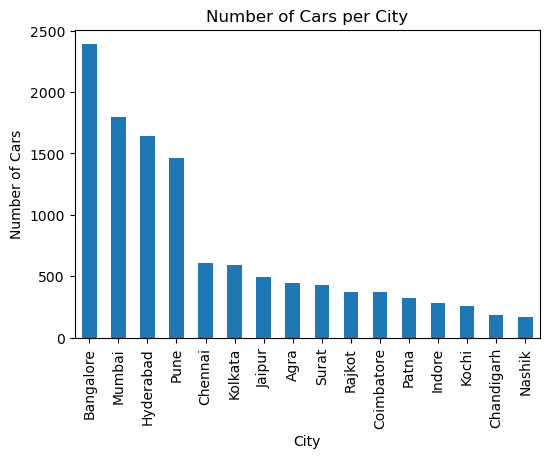

In [343]:
# Number of Cars per City
city_count = df['city'].value_counts()

plt.figure(figsize=(6,4))
city_count.plot(kind='bar')
plt.title("Number of Cars per City")
plt.xlabel("City")
plt.ylabel("Number of Cars")
plt.show()

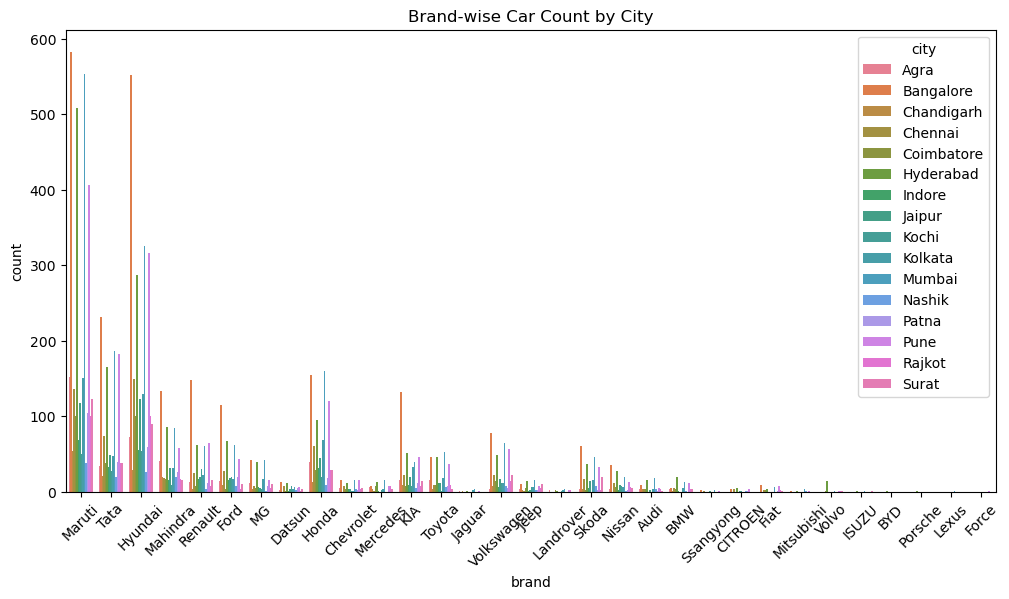

In [344]:
#Brand-wise Car Count for EACH CITY
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='brand', hue='city')
plt.title("Brand-wise Car Count by City")
plt.xticks(rotation=45)
plt.show()

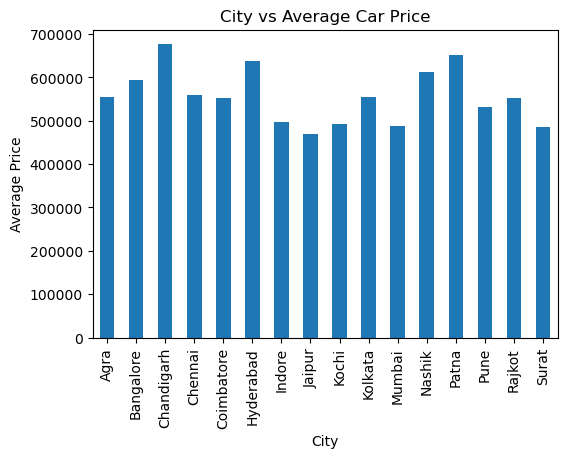

In [345]:
#City vs Average Price
city_avg_price = df.groupby('city')['price'].mean()

plt.figure(figsize=(6,4))
city_avg_price.plot(kind='bar')
plt.title("City vs Average Car Price")
plt.xlabel("City")
plt.ylabel("Average Price")
plt.show()

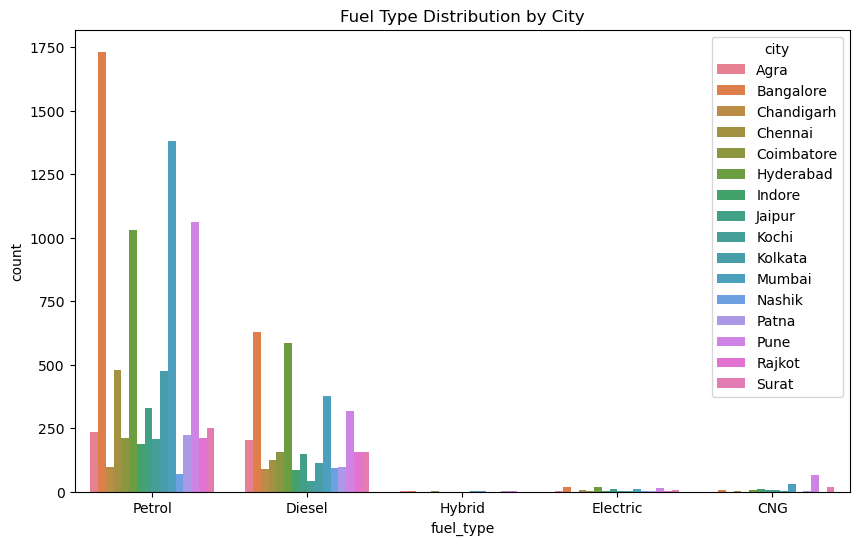

In [346]:
#Fuel Type Distribution by City
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='fuel_type', hue='city')
plt.title("Fuel Type Distribution by City")
plt.show()

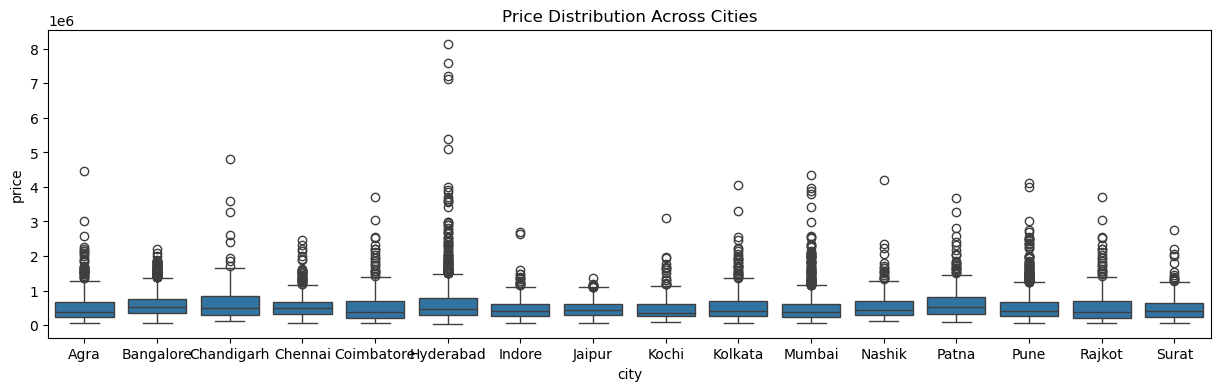

In [347]:
#City-wise Price Distribution (Box Plot)
plt.figure(figsize=(15,4))
sns.boxplot(x='city', y='price', data=df)
plt.title("Price Distribution Across Cities")
plt.show()

In [348]:
#Best Value Cars per City
avg_price_city = df.groupby('city')['price'].transform('mean')

best_value = df[
    (df['price'] < avg_price_city) &
    (df['year_of_manufacture'] >= 2017)
]

best_value[['city', 'brand', 'price', 'year_of_manufacture']].tail()

,city,brand,price,year_of_manufacture
11794,Surat,Maruti,395000.0,2018
11795,Surat,Honda,438000.0,2019
11796,Surat,Renault,203000.0,2019
11797,Surat,Ford,303000.0,2017
11798,Surat,Hyundai,385000.0,2019


In [349]:
df.to_csv("Used_cars_all_cities.csv",index="False")